## Loading Packages, Functions and Data

In [1]:
# import custom functions and required packages from secondary file
from project_functions import *
# turn off warnings
warnings.filterwarnings("ignore")

In [2]:
# Runtime: ~ 3 minutes 
# path to downloaded all match data [UPDATE FILEPATH AS REQUIRED]
path = "/Users/thomaslloyd/Documents/MSc MLDS/Research Project/Code/28196177/"
game_ids = ["COM-000001_DFL-MAT-J03WMX", "COM-000001_DFL-MAT-J03WN1",
            "COM-000002_DFL-MAT-J03WPY", "COM-000002_DFL-MAT-J03WOH",
            "COM-000002_DFL-MAT-J03WQQ", "COM-000002_DFL-MAT-J03WOY",
            "COM-000002_DFL-MAT-J03WR9"]
# create dictionary of all 7 game objects
game_data = {}
for id in game_ids:
    game = import_match_data(id, path)
    game_data.update({id: game})

Reading in /Users/thomaslloyd/Documents/MSc MLDS/Research Project/Code/28196177/DFL_04_03_positions_raw_observed_DFL-COM-000001_DFL-MAT-J03WMX.xml

100%|██████████| 7590415/7590415 [00:10<00:00, 744128.29it/s] 


Reading in /Users/thomaslloyd/Documents/MSc MLDS/Research Project/Code/28196177/DFL_04_03_positions_raw_observed_DFL-COM-000001_DFL-MAT-J03WN1.xml

100%|██████████| 7099405/7099405 [00:08<00:00, 844140.54it/s] 


Reading in /Users/thomaslloyd/Documents/MSc MLDS/Research Project/Code/28196177/DFL_04_03_positions_raw_observed_DFL-COM-000002_DFL-MAT-J03WPY.xml

...

100%|██████████| 6442009/6442009 [00:09<00:00, 712294.87it/s] 


Reading in /Users/thomaslloyd/Documents/MSc MLDS/Research Project/Code/28196177/DFL_04_03_positions_raw_observed_DFL-COM-000002_DFL-MAT-J03WOY.xml

100%|██████████| 6556773/6556773 [00:08<00:00, 786114.07it/s] 


Reading in /Users/thomaslloyd/Documents/MSc MLDS/Research Project/Code/28196177/DFL_04_03_positions_raw_observed_DFL-COM-000002_DFL-MAT-J03WR9.xml

100%|██████████| 6753373/6753373 [00:08<00:00, 819089.77it/s] 


In [3]:
# time adjacent to pass to analyze
seconds_before = 0; seconds_after = 5
# obtain the position data adjacent to pass events
game_pass = {}
for id, game in game_data.items():
    pass_tuple = obtain_pass_trajectories(game, frames_before=seconds_before*25, frames_after=seconds_after*25, velocities=True, acc=True)
    game_pass.update({id : pass_tuple})
# consolidated pass list
pass_event_dict = {id : pass_item[0] for id, pass_item in game_pass.items()}
pass_event_consol = pd.concat(pass_event_dict, names=["match"]).reset_index(level = "match").reset_index(drop=True)

## Pass Event Analysis

Load and analyze the event data. Specifically pass events and their success rate across the different types of pass.

In [4]:
# load event data across all 7 matches (using floodlight package)
event_data = load_event_data(path)
# obtain play events (passes and crosses)
play_events = event_data[event_data["eID"].str.contains("Play_")].reset_index()
play_events = pd.concat([play_events, pd.json_normalize(play_events.qualifier)], axis=1)
play_events["eID_simp"] = play_events["eID"].map(simpl_event)
# clean-up --> set 'successful' evaluation to 'successfullyCompleted'
play_events.loc[play_events.Evaluation == "successful", "Evaluation"] = "successfullyCompleted"
# pivot of 'Plays'
table = pd.pivot_table(play_events, columns="Evaluation", values="index", aggfunc="count",
                       index="eID_simp", margins=True)
table["Success Rate"] = table.iloc[:,0].div(table.iloc[:,-1], axis=0) # success rate
table

Evaluation,successfullyCompleted,unsuccessful,All,Success Rate
eID_simp,,,,
Cross,41,99,140,0.292857
Pass,4209,1032,5241,0.803091
Set Piece Cross,30,59,89,0.337079
Set Piece Pass,474,118,592,0.800676
All,4754,1308,6062,0.784230


In [5]:
# test significance difference between the crosses and non-crosses
crosses = play_events.loc[play_events.eID_simp == "Cross", "Evaluation"] == "successfullyCompleted"
passes = play_events.loc[play_events.eID_simp == "Pass", "Evaluation"] == "successfullyCompleted"
# test difference
stats.ttest_ind(crosses, passes, equal_var=False, alternative="two-sided")

TtestResult(statistic=np.float64(-13.087016327560978), pvalue=np.float64(2.5864207102182993e-26), df=np.float64(144.68658799217232))

## Synchronization: Quality Analysis

Comparing the two synchronization approaches: kick-off lag and Kwiatkowski method. 

Kick-off Lag Corrected Synchronization:


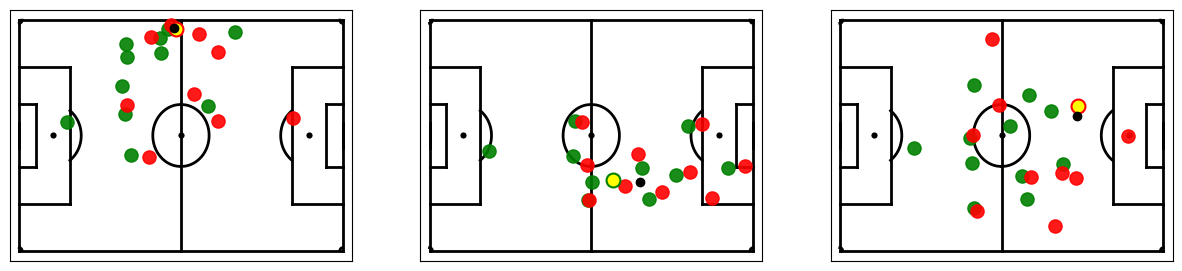

DataBallPy Synchronization:


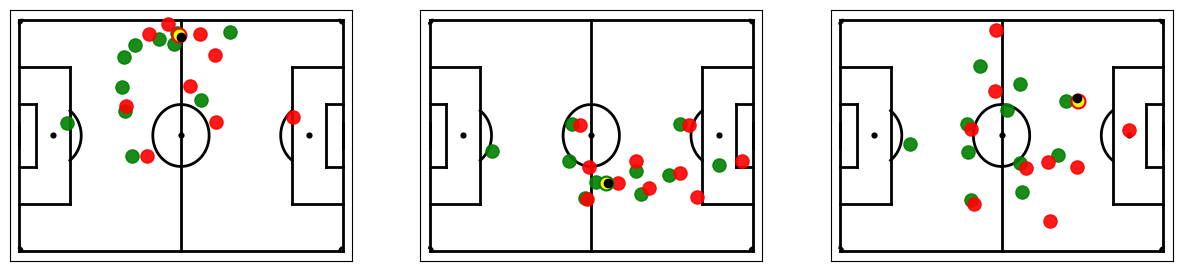

In [6]:
# synchronize the event and position data (using inbuilt function)
boch_lev_game = game_data["COM-000001_DFL-MAT-J03WN1"]
compare_synchronization(boch_lev_game)

Analysing Sync Certainty:

7.5% Quantile: 0.8622338399523153
No. Uncertain Frames: 455


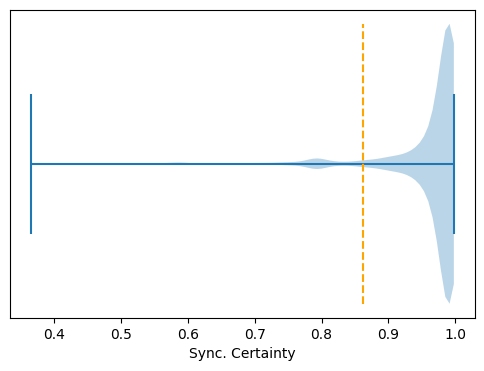

In [7]:
# find 0.05 quantile for Sync Certainty
lq = np.quantile(pass_event_consol["sync_certainty"], q=0.075)
pass_event_consol["certain"] = (pass_event_consol["sync_certainty"] > lq)
print("7.5% Quantile:", lq)
print("No. Uncertain Frames:", np.sum(pass_event_consol["certain"]==False))
# plot histogram of synchronization certainty
plt.figure(figsize=(6, 4)) 
plt.violinplot(pass_event_consol["sync_certainty"], orientation= "horizontal")
plt.vlines(lq,0.75,1.25, linestyles="dashed", colors="orange")
plt.yticks([])
plt.xlabel("Sync. Certainty")
plt.show()

## Post-Pass Time-Frame Analysis

### Time Between Passes

In [8]:
# find the wait times between passes across all games
# Note: Wait time prior to set-piece events is excluded
time_between_passes = np.array([])
for game_id in game_ids:
    time_between_passes = np.append(time_between_passes, pass_interval_times(game_data[game_id]))


In [9]:
# distribution of time between passes
print("Pass Waiting Time Quantile (0.05):", np.quantile(time_between_passes, .05))
print("Pass Waiting Time Median:", np.quantile(time_between_passes, .5))
print("Pass Waiting Time Mean:", np.mean(time_between_passes))
# fit exponential distribution and test fit
pass_lambda = 1/np.mean(time_between_passes)
stat, p_val = stats.kstest(time_between_passes, stats.expon(scale = 1/pass_lambda).cdf)
print("Reject H0 (i.e. Exponenital Distribution): ", p_val<0.05)
mle_shape, _ , mle_scale = stats.gamma.fit(time_between_passes, floc=0)
stat, p_val = stats.kstest(time_between_passes, 'gamma', args=(mle_shape, 0, mle_scale))
print("Reject H0 (i.e. Gamma Distribution): ", p_val<0.05)

Pass Waiting Time Quantile (0.05): 0.96
Pass Waiting Time Median: 2.96
Pass Waiting Time Mean: 3.755591897416837
Reject H0 (i.e. Exponenital Distribution):  True
Reject H0 (i.e. Gamma Distribution):  True


### Time Until Passer's Next Pass

In [10]:
# analyse time until passer's subsequent pass (within the same half)
pass_event_consol_sorted = pass_event_consol.sort_values(["match", "period_id", "player_id", "tracking_frame"])
next_pass = pass_event_consol_sorted.groupby(["match", "period_id", "player_id"])["tracking_frame"].shift(-1)
pass_event_consol["time_till_next_pass"] = (next_pass - pass_event_consol_sorted["tracking_frame"])*1/25
print("Time between player passes (0.05 quanitle):", pass_event_consol["time_till_next_pass"].quantile(0.05))
print("Median Time between player passes (0.5 quanitle):", pass_event_consol["time_till_next_pass"].quantile(0.5))


Time between player passes (0.05 quanitle): 4.882000000000001
Median Time between player passes (0.5 quanitle): 70.0


## Metrics and Measures Relating to Post-Pass Decision Making

### Total Distance Travelled

In [ ]:
# get distance covered by each player after a pass for different post-pass time-frames
# runtime: ~20 seconds
for timeframe in [3, 5, 10]:
    for i in pass_event_consol.index:
        player = pass_event_consol.loc[i, "player_id"]
        match = pass_event_consol.loc[i, "match"]
        game = game_data[match]
        frame = int(pass_event_consol.loc[i, "tracking_frame"])
        pass_event_consol.loc[i, f"distance_covered_{timeframe}"] = get_distance(game, player, frame, 0, timeframe*25)

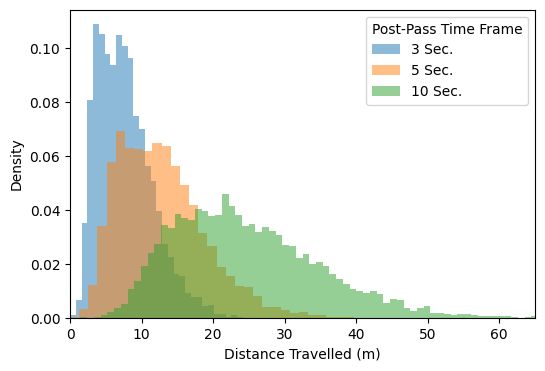

In [13]:
# plot post-pass distance travelled
plt.figure(figsize=(6,4))
for ind, timeframe in enumerate([3, 5, 10]):
    plt.hist(pass_event_consol[f"distance_covered_{timeframe}"], bins= 30*(ind+1), density= True,
             alpha=0.5, label=f"{timeframe} Sec.")
plt.xlim(0,65)
plt.ylabel("Density")
plt.xlabel("Distance Travelled (m)")
plt.legend(title="Post-Pass Time Frame", alignment="left")
plt.show()

In [14]:
# analysing post-pass distances in context
avg_pitch_dim = np.array([game.pitch_dimensions for game in game_data.values()]).mean(axis=0)
# Note: all pitches have same dimension

# median and IQR
for ind, timeframe in enumerate([3, 5, 10]):
    print(f"{timeframe} Seconds")
    print("Min:", np.min(pass_event_consol[f"distance_covered_{timeframe}"]))
    print("Median:", np.median(pass_event_consol[f"distance_covered_{timeframe}"]))
    print("LQ:", (np.quantile(pass_event_consol[f"distance_covered_{timeframe}"], 0.25)))
    print("UQ:", (np.quantile(pass_event_consol[f"distance_covered_{timeframe}"], 0.75)))
    print("IQR:", (np.quantile(pass_event_consol[f"distance_covered_{timeframe}"], 0.75) -
                   np.quantile(pass_event_consol[f"distance_covered_{timeframe}"], 0.25)))
    print("Max:", np.max(pass_event_consol[f"distance_covered_{timeframe}"]), "\n")

3 Seconds
Min: 0.0
Median: 7.149546092502242
LQ: 4.611647288310149
UQ: 9.935555117542833
IQR: 5.3239078292326845
Max: 24.148058811734263 

5 Seconds
Min: 0.0
Median: 12.01285381623687
LQ: 8.024738860833976
UQ: 16.310337156454146
IQR: 8.28559829562017
Max: 76.80265922417614 

10 Seconds
Min: 1.4509351031488884
Median: 23.120478770172944
LQ: 16.90871244050927
UQ: 30.73652249244733
IQR: 13.827810051938062
Max: 86.14592220495071 



### Obtain Post-Pass Trajectories (for Bochum vs Leverkusen Game)


In [15]:
## REMOVE
def plot_trajectory(trajectories, title, ax=None, bounds=25):
    """Function to plot trajectories."""
    if ax is not None:
        for traj in trajectories:
            ax.plot(traj[:,0], traj[:,1], alpha=0.5, c= "tab:blue", linewidth=.3)
            ax.set_title(title)
            ax.set_xlim([-bounds, bounds])
            ax.set_ylim([-bounds, bounds])
    else:
        for traj in trajectories:
            plt.plot(traj[:,0], traj[:,1], alpha=0.5, c= "o", linewidth=.3)
        plt.title(title)    
        plt.show()
        
def plot_trajectory_times(game):
    """Function to plot different lengths of post-pass trajectories."""
    seconds_after = [3,5,10]
    fig, ax = plt.subplots(1, 3, figsize = (15,4))
    for ind, time in enumerate(seconds_after):
        # obtain passer trajectories for 5 seconds to pass events
        pass_events, passer_traj = obtain_pass_trajectories(game, frames_before=0,
                                                            frames_after=25*time)
        nsp_traj = passer_traj
        plot_trajectory(nsp_traj, f"{time} Seconds", ax[ind])
        ax[ind].grid(alpha=0.5)
        ax[ind].set_xlabel("Longitudinal Displacement (m)")
        ax[ind].set_ylabel("Lateral Displacement (m)")
    plt.show()

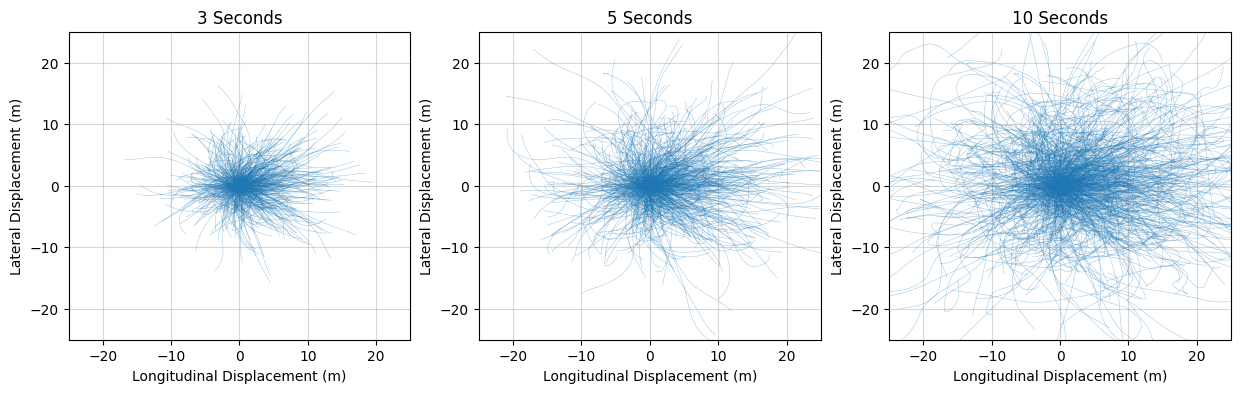

In [16]:
 # plot post-pass trajectories for example game for differing post-pass intervals
boch_lev_game = game_data["COM-000001_DFL-MAT-J03WN1"]
plot_trajectory_times(boch_lev_game)

## Post-Pass Trajectory Extraction

In [17]:
# extract post-pass movement centered trajectories
pass_event_consol[f"post_pass_5_cent"] =  pd.Series([None] * len(pass_event_consol), dtype="object")

for match, game in game_data.items():
    ind = pass_event_consol["match"]==match
    for t in [5]:
        _, pass_traj = obtain_pass_trajectories(game, frames_before=0, frames_after=25*t,centered=True)
        pass_event_consol.loc[ind,f"post_pass_{t}_cent"] =  pd.Series(list(pass_traj)).values

### Goalkeepers have differing post-pass movements

In [18]:
## remove
def plot_trajectories_goalkeeper(game, roles):
    """Function to plot post-pass trajectories by passer role."""
    pass_events, passer_traj = obtain_pass_trajectories(game, frames_before=0, frames_after=25*3)
    fig, ax = plt.subplots(2, 4, figsize = (15,8))
    for ind, role in enumerate(roles):
        role_trajectory = passer_traj[((pass_events["role"]==role) &
                                    (pass_events["set_piece"]=="no_set_piece"))]
        plot_trajectory(role_trajectory, role, ax[ind//2, ind % 2], bounds=15)
    # plot density plot of final locations
    for ind, role in enumerate(roles):
        role_trajectory = passer_traj[(pass_events["role"]==role) & (pass_events["set_piece"]=="no_set_piece")]
        plot_final_location(role_trajectory, role, ax[ind//2, 2+ind % 2], bounds=15)
    plt.show()

In [19]:
## remove
def plot_trajectories_goalkeeper(pass_event_consol):
    """Function to plot post-pass trajectories final location for outfield player vs goalkeeper."""
    # plot density plot for goalkeeper vs non-goalkeeper
    fig, ax = plt.subplots(1,2, figsize =(12,4))
    x_bounds = 30
    y_bound = 20
    # plot for goalkeeper
    gk_fl = pass_event_consol[pass_event_consol["role"]=="goalkeeper"]["post_pass_5_fl"]
    ax[0].set_title("Goalkeeper")
    ax[0].set_xlim([-x_bounds, x_bounds])
    ax[0].set_ylim([-y_bound, y_bound])
    ax[0].set_aspect('equal')
    sns.kdeplot(x=gk_fl.apply(lambda x: x[0]), y=gk_fl.apply(lambda x: x[1]), cmap="Blues", fill=True, ax=ax[0], shade=True)
    ax[0].set_xlabel("Longidudinal Displacement (m)")
    ax[0].set_ylabel("Lateral Displacement (m)")
    ax[0].grid(alpha=0.25)
    # plot for non goalkeeper
    ngk_fl = pass_event_consol[pass_event_consol["role"]!="goalkeeper"]["post_pass_5_fl"]
    ax[1].set_title("Outfield")
    ax[1].set_xlim([-x_bounds, x_bounds])
    ax[1].set_ylim([-y_bound, y_bound])
    ax[1].set_aspect('equal')
    ax[1].set_xlabel("Longidudinal Displacement (m)")
    sns.kdeplot(x=ngk_fl.apply(lambda x: x[0]), y=ngk_fl.apply(lambda x: x[1]), cmap="Blues", fill=True, ax=ax[1], shade=True)
    ax[1].set_ylabel("Lateral Displacement (m)")
    ax[1].grid(alpha=0.25)
    plt.show()

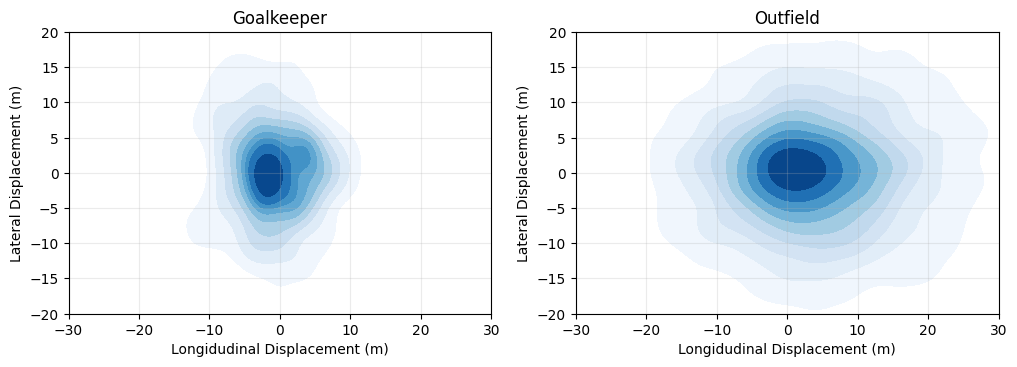

In [20]:
# obtain final location of each passer relative trajectory after 5 seconds
pass_event_consol["post_pass_5_fl"] = pass_event_consol["post_pass_5_cent"].apply(lambda x: x[-1])
plot_trajectories_goalkeeper(pass_event_consol)


# Post-Pass Metric Extraction

In [22]:
# set post pass time frame
pp_tf=5

In [23]:
# extract post-pass movement raw trajectories
pass_event_consol[f"post_pass_5"] =  pd.Series([None] * len(pass_event_consol), dtype="object")

for match, game in game_data.items():
    ind = pass_event_consol["match"]==match
    for t in [5]:
        _, pass_traj = obtain_pass_trajectories(game, frames_before=0, frames_after=25*t,centered=False)
        pass_event_consol.loc[ind,f"post_pass_{t}"] =  pd.Series(list(pass_traj)).values

In [ ]:
# remove poorly synched passes
pass_event_consol = pass_event_consol[pass_event_consol["certain"]==True].reset_index()

## Time Series Features
The following functions allow the extraction of the required features from time series.

In [25]:
# define functions to extract 'bespoke' features from time series
# Note: Some features are defined in 

def max_decrease(time_series):
    """Function to find maximum reduction relevant to starting value of time series."""
    max_dec =  time_series[0] - np.min(time_series)
    if max_dec>0:
        return max_dec
    else:
        return np.NaN


def max_increase(time_series):
    """Function to find maximum reduction relevant to starting value of time series."""
    max_inc = np.max(time_series) - time_series[0]
    if max_inc >0:
        return max_inc
    else:
        return np.NaN


def approx_entropy(time_series, run_length, filter_level):
    """Approximate Entropy (ApEn) of a time series."""

    r = filter_level

    def phi(m):
        # Shape: (N-m+1, m)
        X = sliding_window_view(time_series, m)
        
        # Pairwise Chebyshev (maximum) distances
        dist = np.abs(X[:, None, :] - X[None, :, :]).max(axis=2)

        # proportion of matches
        C = (dist < r).mean(axis=1)

        return np.log(C).mean()

    return abs(phi(run_length + 1) - phi(run_length))


def time_to_zero(time_series):
    """Function to extract how long time series takes to reach a 0 value.
    If time series does not reach 0, value is undefined."""
    if np.any(time_series == 0):
        return (np.where(time_series == 0)[0][0])*1/25
    else:
        return np.nan

## Out-of-Position Detection Model

### MLE Model

In [26]:
## remove
from sklearn.covariance import MinCovDet
from scipy.stats import multivariate_normal

In [27]:
def get_pos_5_min_mvn(match, player, frame):
    """Get players average position for 2.5 minutes either side of a given frame."""
    game = game_data[match]
    alive = game.tracking_data.loc[frame-3750 : frame+3750]
    alive = np.array([alive[f"{player}_x"].values, alive[f"{player}_y"].values]).T
    alive = alive[~np.isnan(alive).any(axis=1)]
    mean, cov = stats.multivariate_normal.fit(alive)
    return mean, cov


def get_5mr_mvn(match, player, frame):
    """Function to extract distance between passer and their average match position in 2.5 mins either side of a pass."""
    game = game_data[match]
    pid = game.player_id_to_column_id(player)
    player_mean_pos = get_pos_5_min_mvn(match, pid, frame)
    return player_mean_pos

pass_event_consol["5m_mle"] = pass_event_consol.apply(lambda x: get_5mr_mvn(x["match"], x["player_id"], x["tracking_frame"]), axis=1)

### MCD Model

In [ ]:
# runtime ~ 1 min
def get_pos_5_min_mvn_mcd(match, player, frame):
    """Get players average position for 2.5 minutes either side of a given frame."""
    game = game_data[match]
    pid = game.player_id_to_column_id(player)
    alive = game.tracking_data.loc[frame-3750 : frame+3750]
    alive = np.array([alive[f"{pid}_x"].values, alive[f"{pid}_y"].values]).T
    # downsample for efficiency
    alive = alive[~np.isnan(alive).any(axis=1)][::25,:]
    
    # Robust fit
    mcd = MinCovDet(random_state=0).fit(alive)
    mu_hat = mcd.location_
    Sigma_hat = mcd.covariance_
    return mu_hat, Sigma_hat

pass_event_consol["5m_mcd"] = pass_event_consol.apply(lambda x: get_pos_5_min_mvn_mcd(x["match"], x["player_id"], x["tracking_frame"]), axis=1)

### Detecting Out-of-Position Passers

In [29]:
def out_of_position(pass_loc, mle_est, lim):
    mu, sigma = mle_est
    chi_sq = (pass_loc- mu).reshape(1,-1)@np.linalg.inv(sigma)@(pass_loc- mu).reshape(-1,1)
    return stats.chi2(df=2).cdf(chi_sq[0][0]) > lim

# passer out of position at time of pass
pass_event_consol["out_of_position_s"] = pass_event_consol.apply(lambda x: out_of_position(x["post_pass_5"][0], x["5m_mcd"], lim=0.95),axis=1)
# passer out of position after post-pass interval
pass_event_consol["out_of_position_e"] = pass_event_consol.apply(lambda x: out_of_position(x["post_pass_5"][-1], x["5m_mcd"], lim=0.95),axis=1)
# passer was out of position and moved back into position
pass_event_consol["outp2inp"] = (pass_event_consol["out_of_position_s"] == True) & (pass_event_consol["out_of_position_e"] == False)

## Passer Moves to Cover Opponent

### Distance to Closest Opponent

In [ ]:
# runtime ~ 30 seconds
def get_d2co(match, team, player, frame, frames_before, frames_after):
    """Function to extract distance between passer and the closest average position of a teammate."""
    game = game_data[match]
    pid = game.player_id_to_column_id(player)
    
    passer_loc = game.tracking_data.loc[frame + frames_before : frame + frames_after, [f"{pid}_x", f"{pid}_y"]].to_numpy()
    if team == "home":
        opp_loc = np.array([game.tracking_data.loc[frame + frames_before : frame + frames_after, [f"{opp}_x", f"{opp}_y"]].to_numpy() for opp in game.get_column_ids() if opp[:4]=="away"])
    else:
        opp_loc = np.array([game.tracking_data.loc[frame + frames_before : frame + frames_after, [f"{opp}_x", f"{opp}_y"]].to_numpy() for opp in game.get_column_ids() if opp[:4]!="away"])
    min_dist = np.nanmin(np.linalg.norm(passer_loc[None,:,:] - opp_loc, axis=2),axis=0)
    return min_dist

pass_event_consol["d2co_ts"] = pass_event_consol.apply(lambda x: get_d2co(x["match"], x["team_side"], x["player_id"], x["tracking_frame"], 0, 25*pp_tf), axis=1)

The maximal decrease and minimum distance are extracted...

In [31]:
# maximal decrease
pass_event_consol['d2co_ts_max_dec'] = pass_event_consol['d2co_ts'].map(max_decrease)
# maximal decrease (ind)
pass_event_consol['d2co_ts_max_dec_ind'] = ~pass_event_consol['d2co_ts_max_dec'].isna()
# minimum
pass_event_consol['d2co_ts_min'] = pass_event_consol['d2co_ts'].map(np.min)


Indicator for a player moving closer to opponent...

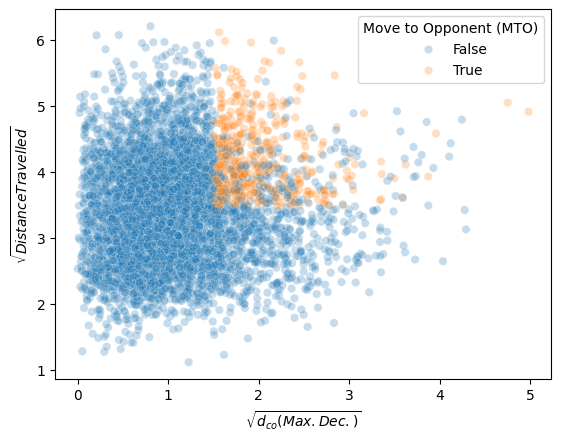

In [32]:
# upper quantile of maximal decrease
co_q3 = np.nanquantile(pass_event_consol['d2co_ts_max_dec'], 0.75)
# median quantile of distance travelled
d_q2 = np.nanquantile(pass_event_consol['distance_covered_5'], 0.5)

# bucket to analyse
bucket = (pass_event_consol["d2co_ts_max_dec"]>co_q3)&(pass_event_consol["distance_covered_5"]>d_q2)& (pass_event_consol["d2co_ts_min"]<3)

sns.scatterplot(x = np.sqrt(pass_event_consol['d2co_ts_max_dec']), 
                y = np.sqrt(pass_event_consol['distance_covered_5']),
                alpha=0.25,
                hue=bucket)
plt.xlabel("$\sqrt{d_{co}(Max. Dec.)}$"); plt.ylabel("$\sqrt{Distance Travelled}$")
plt.legend(title="Move to Opponent (MTO)")
plt.show()

# define 'moved to opponent' indicator
pass_event_consol['m2o'] = bucket

## Coordination with Teammates

### Displacement from Team Centroid

In [ ]:
# runtime: ~40 seconds
def get_team_centroid(match, first_frame, last_frame, team="home", exclude_goalkeeper=True):
    """Function to calculate centroid of a team at a given frame."""
    game = game_data[match]
    player_ids = game.get_column_ids(team=team, idx=first_frame)
    if exclude_goalkeeper:
        players_df = game.home_players if team == "home" else game.away_players

        gk_id = players_df.loc[players_df["position"] == "goalkeeper", "id"].tolist()
        gk_id = [game.player_id_to_column_id(id) for id in gk_id]

        player_ids = [pid for pid in player_ids if pid not in gk_id]

    frame = game.tracking_data.iloc[first_frame:last_frame+1, :]
    coords = np.array([
        [frame[f"{pid}_x"], frame[f"{pid}_y"]]
        for pid in player_ids
    ], dtype=float)
    
    # coords = coords[~np.isnan(coords).any(axis=(1,2))]
    
    return np.nanmean(coords,axis=0)


def get_d2tloc_ts(match, player, team, first_frame, last_frame):
    "Function to calculate the displacement of a player from the team longitudional centroid (excluding goalkeeper)."
    
    team_centroid = get_team_centroid(match, first_frame, last_frame, team=team)
    game = game_data[match]
    pid = game.player_id_to_column_id(player)
    passer_loc = game.tracking_data.loc[first_frame:last_frame, [f"{pid}_x"]].to_numpy().T

    return (passer_loc - team_centroid[0])[0]

def get_d2tlac_ts(match, player, team, first_frame, last_frame):
    "Function to calculate the displacement of a player from the team lateral centroid (excluding goalkeeper)."
    
    team_centroid = get_team_centroid(match, first_frame, last_frame, team=team)
    game = game_data[match]
    pid = game.player_id_to_column_id(player)
    passer_loc = game.tracking_data.loc[first_frame:last_frame, [f"{pid}_y"]].to_numpy().T

    return (passer_loc - team_centroid[1])[0]


pass_event_consol["d2tloc_ts"] = pass_event_consol.apply(lambda x: get_d2tloc_ts(x["match"], x["player_id"], x["team_side"],
                                                                                 x["tracking_frame"], x["tracking_frame"]+ 25*pp_tf), axis=1)
pass_event_consol["d2tlac_ts"] = pass_event_consol.apply(lambda x: get_d2tlac_ts(x["match"], x["player_id"], x["team_side"],
                                                                                 x["tracking_frame"], x["tracking_frame"]+ 25*pp_tf), axis=1)

Obtain spread features and approximate entropy...

In [34]:
man_cols = ['d2tloc_ts', 'd2tlac_ts']

# range
range_man_col = [col+"_range" for col in man_cols]
pass_event_consol[range_man_col] = pass_event_consol[man_cols].map(lambda x: np.max(x)-np.min(x))

# standard deviation
std_man_col = [col+"_std" for col in man_cols]
pass_event_consol[std_man_col] = pass_event_consol[man_cols].map(np.std)

# ApEn on each manoeuvring time series
def apen_add(pass_record, columns, std_list):
    features = []
    for ind, col in enumerate(columns):
        std = std_list[ind]
        features += [approx_entropy(pass_record[col], 2, 0.2*std)]
    return np.array(features)

std_list = pass_event_consol[man_cols].map(np.std).apply(np.median, axis=0).values
ae_man_col = [col+"_ae" for col in man_cols]
pass_event_consol[ae_man_col] = pd.DataFrame(np.stack(pass_event_consol[man_cols].apply(lambda x: apen_add(x, man_cols, std_list),axis=1)))


### Displacement from Role Centroid

In [ ]:
# runtime: ~20 seconds
def get_d2rc_ts(match, team, role, player_id, frame, frames_before, frames_after, long_lat):
    """Distance between player and their role centroid."""
    
    game = game_data[match]

    # role centroid
    tracking_data = game.tracking_data.iloc[frame:frame+frames_after+1, :]
    players_df = game.home_players if team == "home" else game.away_players
    role_players = [game.player_id_to_column_id(id) for id, p_role in zip(players_df["id"], players_df["position"]) if p_role == role]
    coords = np.array([[tracking_data[f"{pid}_x"], tracking_data[f"{pid}_y"]] for pid in role_players], dtype=float)
    role_centroid = np.nanmean(coords, axis=0)
    
    # player trajectory
    pid = game.player_id_to_column_id(player_id)
    passer_loc = game.tracking_data.loc[(frame- frames_before) : (frame+ frames_after), [f"{pid}_x", f"{pid}_y"]].to_numpy().T
    
    if long_lat == "long":
        return passer_loc[0,:] - role_centroid[0]
    elif long_lat == "lat":
        return passer_loc[1,:] - role_centroid[1]

pass_event_consol["d2lorc_ts"] = pass_event_consol.apply(lambda x: get_d2rc_ts(x["match"],x["team_side"], x["role"], x["player_id"], x["tracking_frame"], 0, 25*pp_tf, long_lat="long"), axis=1)
pass_event_consol["d2larc_ts"] = pass_event_consol.apply(lambda x: get_d2rc_ts(x["match"],x["team_side"], x["role"], x["player_id"], x["tracking_frame"], 0, 25*pp_tf, long_lat="lat"), axis=1)

Complete similar feature extraction:

In [ ]:
# runtime: ~ 10 seconds
man_cols = ['d2lorc_ts', 'd2larc_ts']

# range
range_man_col = [col+"_range" for col in man_cols]
pass_event_consol[range_man_col] = pass_event_consol[man_cols].map(lambda x: np.max(x)-np.min(x))

# standard deviation
std_man_col = [col+"_std" for col in man_cols]
pass_event_consol[std_man_col] = pass_event_consol[man_cols].map(np.std)

# ApEn on each manoeuvring time series
def apen_add(pass_record, columns, std_list):
    features = []
    for ind, col in enumerate(columns):
        std = std_list[ind]
        features += [approx_entropy(pass_record[col], 2, 0.2*std)]
    return np.array(features)

std_list = pass_event_consol[man_cols].map(np.std).apply(np.median, axis=0).values
ae_man_col = [col+"_ae" for col in man_cols]
pass_event_consol[ae_man_col] = pd.DataFrame(np.stack(pass_event_consol[man_cols].apply(lambda x: apen_add(x, man_cols, std_list),axis=1)))

## Runs

### Pressure

In [ ]:
# runtime: ~ 3 mins
def get_pressure_ts(match, player, frame, frames_after):
    """Function to obtain pressure on player at given frame."""
    game = game_data[match]
    pid = game.player_id_to_column_id(player)
    f = lambda x: game.tracking_data.get_pressure_on_player(x, pid, game.pitch_dimensions)
    f = np.vectorize(f)
    pressure = f(np.arange(frame, frame + frames_after+1))
    return pressure

pass_event_consol["pressure_ts"] = pass_event_consol.apply(lambda x: get_pressure_ts(x["match"], x["player_id"], x["tracking_frame"], 25*pp_tf), axis=1)

What is 'high pressure'?

% 0 Values: 31.335830212234704


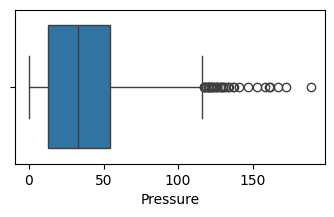

Median (Non-zero): 32.59532981556478


In [39]:
# obtain intial pressure
pass_event_consol["pressure_ts_init"] = pass_event_consol["pressure_ts"].map(lambda x: x[0])
# visualize distribution
print("% 0 Values:", np.mean(pass_event_consol["pressure_ts_init"]==0)*100)
plt.figure(figsize=(4,2))
sns.boxplot(x=pass_event_consol[pass_event_consol["pressure_ts_init"]!=0]["pressure_ts_init"],)
plt.xlabel("Pressure")
plt.show()
hp = np.quantile(pass_event_consol[pass_event_consol["pressure_ts_init"]!=0]["pressure_ts_init"], q=0.5)
print("Median (Non-zero):", hp)
pass_event_consol["hp_pass"] = pass_event_consol["pressure_ts_init"]>hp

Time to 0 pressure feature extracted...

In [40]:
# time to zero
pass_event_consol['pressure_ts_drop_time'] = pass_event_consol['pressure_ts'].apply(time_to_zero)

# high pressure to low pressure
pass_event_consol['hp2lp'] = pass_event_consol['hp_pass'] & (~pass_event_consol['pressure_ts_drop_time'].isna())


In [41]:
# how many high pressure passes return to zero
np.sum(pass_event_consol['hp_pass'] & (~pass_event_consol['pressure_ts_drop_time'].isna()))/np.sum(pass_event_consol['hp_pass'])

np.float64(0.6685714285714286)

### Opposition Surface Area

In [ ]:
# runtime: ~1 min
# convex hull surface area
def get_team_area_ts(match, team, frame_id, num_frames, exclude_goalkeeper=True):
    """Find area of convex hull of a given team at a given frame."""
    game = game_data[match]
    if team == "home":
        player_ids = game.get_column_ids(team="away", idx=frame_id)
    else:
        player_ids = game.get_column_ids(team="home", idx=frame_id)
    
    if exclude_goalkeeper:
        players_df = game.home_players if team == "away" else game.away_players

        gk_id = players_df.loc[players_df["position"] == "goalkeeper", "id"].tolist()
        gk_id = [game.player_id_to_column_id(id) for id in gk_id]

        player_ids = [pid for pid in player_ids if pid not in gk_id]

    tracking_data = game.tracking_data.iloc[frame_id:frame_id+num_frames+1,:]
    coords = np.array([[tracking_data[f"{pid}_x"], tracking_data[f"{pid}_y"]] for pid in player_ids], dtype=float)
    coords = coords[~np.isnan(coords).any(axis=(1,2))]
    sa = np.array([])
    for f in range(num_frames+1):
        sa = np.append(sa, spatial.ConvexHull(coords[:,:,f]).volume)
    return sa

pass_event_consol["sa_ts"] = pass_event_consol.apply(lambda x: get_team_area_ts(x["match"], x["team_side"], x["tracking_frame"], 25*pp_tf), axis=1)

### Opposition Spread

In [ ]:
# runtime: ~30 seconds
def get_frob_norm_ts(match, team, frame_id, num_frames, exclude_goalkeeper=True):
    """Find area of convex hull of a given team at a given frame."""
    
    game = game_data[match]
    
    # opposition coordinates
    if team == "home":
        player_ids = game.get_column_ids(team="away", idx=frame_id)
    else:
        player_ids = game.get_column_ids(team="home", idx=frame_id)
    
    if exclude_goalkeeper:
        players_df = game.home_players if team == "away" else game.away_players

        gk_id = players_df.loc[players_df["position"] == "goalkeeper", "id"].tolist()
        gk_id = [game.player_id_to_column_id(id) for id in gk_id]

        player_ids = [pid for pid in player_ids if pid not in gk_id]

    frame = game.tracking_data.iloc[frame_id: frame_id + num_frames,:]
    
    coords = np.array([[frame[f"{pid}_x"], frame[f"{pid}_y"]] for pid in player_ids], dtype=float)
    
    # remove players with NA values (i.e. not playing)
    coords = coords[~np.isnan(coords).any(axis=(1,2))]
    
    spread = np.array([])
    for f in range(num_frames):
        # Frobenius norm
        pdist = spatial.distance.pdist(coords[:,:,f])
        pdist = np.tril(pdist, k=1)
        spread = np.append(spread, np.sqrt(np.sum(pdist**2)))
    
    return spread

pass_event_consol["sp_ts"] = pass_event_consol.apply(lambda x: get_frob_norm_ts(x["match"], x["team_side"], x["tracking_frame"], 25*pp_tf), axis=1)

Maximum increase for the team spread measures...

In [44]:
run_cols = ['sa_ts', 'sp_ts']

# max increase
max_inc_run_col = [col+"_max_inc" for col in run_cols]
pass_event_consol[max_inc_run_col] = pass_event_consol[run_cols].map(max_increase)

# add indicator for no increase
no_inc_run_col = [col+"_no_inc" for col in run_cols]
pass_event_consol[no_inc_run_col] = pass_event_consol[max_inc_run_col].map(lambda x: np.isnan(x))


### One-Two (Subsequent pass is back to orignal passer)

In [ ]:
# indicator of whether passer receives the subsequent pass
pass_event_consol["subsequent_pass_reciever"] = pass_event_consol.sort_values(["match", "period_id", "tracking_frame"]).groupby(["match", "period_id"])["receiver_player_id"].shift(-1)
pass_event_consol["one_two"] = pass_event_consol["player_id"] == pass_event_consol["subsequent_pass_reciever"] 
pass_event_consol["one_two"].value_counts()

one_two
False    4961
True      646
Name: count, dtype: int64

### Save Dataframe

In [46]:
# save pandas DataFrame
pass_event_consol.to_pickle("consol.pkl")

### Re-import Data

In [ ]:
import pickle
pass_event_consol = pickle.load(open('consol.pkl', 'rb'))

# Consolidated Post-Pass Embedding

In [ ]:
column_dict = {'outp2inp':"OP2IP", 'd2co_ts_max_dec':"$\\text{CO}_{\\text{MD}}$", 'd2tloc_ts_range':"$\\text{TLoC}_{r}$", "d2co_ts_max_dec_ind":"$\\text{CO}_{\\text{MD}>0}$",
               'd2tlac_ts_range':"$\\text{TLaC}_{r}$",'d2tloc_ts_ae':"$\\text{TLoC}_{\\text{AE}}$", 'd2tlac_ts_ae':"$\\text{TLaC}_{\\text{AE}}$",
               'hp_pass':"$\\text{HP}$", 'pressure_ts_drop_time':"$\\text{P}_{\\text{DT}}$",'sa_ts_max_inc':"$\\text{SA}_{\\text{MI}}$",
               'sp_ts_max_inc':"$\\text{Frob}_{\\text{MI}}$", 'sa_ts_no_inc':"$\\text{SA}_{\\text{NI}}$",
               'sp_ts_no_inc':"$\\text{Frob}_{\\text{NI}}$",'one_two':"$\\text{OT}$", "hp2lp":"HP2LP", "m2o":"M2O"}
# post-pass embedding
col_names = ["outp2inp", "m2o", "d2tloc_ts_range", "d2tlac_ts_range",
             "d2tloc_ts_ae", "d2tlac_ts_ae", "hp2lp", 'sa_ts_no_inc', "sa_ts_max_inc",  'sp_ts_no_inc',
             "sp_ts_max_inc", "one_two"]
# remove uncertain frames
pass_event_consol_is = pass_event_consol[pass_event_consol["certain"]==True]
post_pass_emb = pass_event_consol_is[col_names]
post_pass_emb
# binary variable columns
bin_cols = ["outp2inp", "m2o", "hp2lp",'sa_ts_no_inc', 'sp_ts_no_inc', "one_two"]
# continuous variable columns
cont_cols = ["d2tloc_ts_range", "d2tlac_ts_range",
             "d2tloc_ts_ae", "d2tlac_ts_ae",
             "sa_ts_max_inc", "sp_ts_max_inc"]

## Analyse the continuous variables shape 

To normalize the variables fit and apply box-cox transformations.

In [ ]:
import scipy
import scipy.stats as stats

In [ ]:
# apply box cox to continuous variables
post_pass_emb_t = post_pass_emb.copy()
box_cox_lambda = {}
for col in cont_cols:
    box_cox_t, lamb = stats.boxcox(post_pass_emb[col][~post_pass_emb[col].isna()])
    box_cox_lambda[col] = lamb
    post_pass_emb_t.loc[~post_pass_emb[col].isna(), col] =box_cox_t
    

In [ ]:

## appendix box-cox normality
fig, ax = plt.subplots(6, 2, figsize=(7,15))

for ind, col in enumerate(cont_cols):
    sns.histplot(post_pass_emb[col][~post_pass_emb[col].isna()], bins=30, ax=ax[ind,0], stat="proportion")
    sns.histplot(post_pass_emb_t[col][~post_pass_emb_t[col].isna()], bins=30, ax=ax[ind,1],stat="proportion")
    ax[ind,1].set_ylabel("")
    ax[ind,0].set_xlabel(""); ax[ind,1].set_xlabel("")
    ax[ind,0].text(0.99, 0.99, f"{column_dict[col]}\n(Raw)", transform=ax[ind,0].transAxes, horizontalalignment="right", verticalalignment="top")
    ax[ind,1].text(0.99, 0.99, f"{column_dict[col]}\n(Box-Cox)", transform=ax[ind,1].transAxes, horizontalalignment="right", verticalalignment="top")
plt.show()

In [ ]:
# # attempt to normalize variables by sqrt transformation
# post_pass_emb = post_pass_emb.map(np.sqrt, dtype="float64")
# post_pass_emb

## Correlation between variables
* Spearman Rank between two continuous
* Phi between two binary
* Point biserial correlation

In [ ]:
post_pass_emb_t.corr(method="pearson")

In [ ]:
# compare correlation
sns.set_style("white")
sns.heatmap(post_pass_emb_t.rename(columns=column_dict).corr(method="pearson"), vmin=-1, vmax=1,cmap="bwr",annot=True, fmt=".2f", annot_kws={"fontsize":8})
plt.xticks(rotation=45)
plt.show()

## Role and Set Piece

### Set-Piece

In [ ]:
# passes by set piece
pass_event_consol_is["set_piece"].value_counts()

In [ ]:
# ANOVA test for continuous variables
set_piece_list = pass_event_consol_is["set_piece"].unique()

anova_set_piece = pd.DataFrame()
for col in cont_cols:
    set_piece_df = [post_pass_emb_t[pass_event_consol_is["set_piece"]==set_piece][col] for set_piece in set_piece_list]
    test = stats.f_oneway(*set_piece_df, equal_var=True,nan_policy="omit")
    F, p = test.statistic, test.pvalue
    anova_set_piece = pd.concat([anova_set_piece, pd.DataFrame(np.array([F,p])[None,:],columns=["F", "p"],index =[col])], axis=0)
    
anova_set_piece

In [ ]:
matrix = pd.DataFrame()
for col in cont_cols:
    set_piece_df = [post_pass_emb_t[(pass_event_consol_is["set_piece"]==set_piece)&(~pass_event_consol_is[col].isna())][col] for set_piece in set_piece_list]
    nsp = pd.DataFrame(stats.tukey_hsd(*set_piece_df, equal_var=True).pvalue,index=set_piece_list, columns=set_piece_list).iloc[:,0]
    matrix = pd.concat([matrix, nsp],axis=1)
matrix.columns = cont_cols
matrix

In [ ]:
matrix < (0.05/(5*6))

Now for **binary** variables...

In [ ]:
pass_event_consol_is.groupby(["set_piece"])[bin_cols].agg([np.sum, len, lambda x: np.sum(x)/len(x)])

In [ ]:
pass_event_consol_is.groupby(["set_piece"])[bin_cols].sum()/pass_event_consol_is.groupby(["set_piece"])[bin_cols].count()

In [ ]:
# exclude corners and kick-offs as <5 expected frequencies
no_c_ko = pass_event_consol_is[~pass_event_consol_is["set_piece"].isin(["kick_off","corner_kick"])]

chisq_set_piece= pd.DataFrame()

for col in bin_cols:
    observed = pd.crosstab(no_c_ko["set_piece"], no_c_ko[col])
    chi2_test = stats.chi2_contingency(observed)
    F, p = chi2_test.statistic, chi2_test.pvalue
    chisq_set_piece = pd.concat([chisq_set_piece, pd.DataFrame(np.array([F,p])[None,:],columns=["F", "p"],index =[col])], axis=0)
chisq_set_piece.rename(index=column_dict)

In [ ]:
chisq_set_piece= pd.DataFrame()

for col in bin_cols:
    p_vals = []
    for set_piece in ['throw_in', 'goal_kick','free_kick']:
        no_c_ko_filter = no_c_ko[no_c_ko["set_piece"].isin([set_piece, "no_set_piece"])]
        observed = pd.crosstab(no_c_ko_filter["set_piece"], no_c_ko_filter[col])
        chi2_test = stats.chi2_contingency(observed)
        F, p = chi2_test.statistic, chi2_test.pvalue
        p_vals += [p]
    chisq_set_piece = pd.concat([chisq_set_piece, pd.DataFrame(np.array(p_vals)[None,:],columns=['throw_in', 'goal_kick','free_kick'],index =[col])], axis=0)
chisq_set_piece.rename(index=column_dict).T

In [ ]:
# test results
chisq_set_piece.rename(index=column_dict).T<0.05/18

# Gower Distance

In [ ]:
# instead of 0 use median non-zero
post_pass_emb.loc[post_pass_emb['sa_ts_no_inc'], 'sa_ts_max_inc'] = post_pass_emb.loc[post_pass_emb['sa_ts_no_inc']==False, 'sa_ts_max_inc'].median()
post_pass_emb.loc[post_pass_emb['sp_ts_no_inc'], 'sp_ts_max_inc'] = post_pass_emb.loc[post_pass_emb['sp_ts_no_inc']==False, 'sp_ts_max_inc'].median()

# instead of 0 use median non-zero
pass_event_consol_is.loc[pass_event_consol_is['sa_ts_no_inc'], 'sa_ts_max_inc'] = pass_event_consol_is.loc[pass_event_consol_is['sa_ts_no_inc']==False, 'sa_ts_max_inc'].median()
pass_event_consol_is.loc[pass_event_consol_is['sp_ts_no_inc'], 'sp_ts_max_inc'] = pass_event_consol_is.loc[pass_event_consol_is['sp_ts_no_inc']==False, 'sp_ts_max_inc'].median()

# gower distance embedding
emb_gower_dist = gower.gower_matrix(post_pass_emb, cat_features=[True,True,False,False,False,False,True,True,False,True,False,True])
emb_gower_dist

### k-Medoid Clustering

In [ ]:
# k-medoids

import kmedoids
sil_scores = []
med_sil_scores = []
k_values = [i for i in range(2,21,1)]
for k in k_values:
    kmed = kmedoids.pam(emb_gower_dist, k, random_state=1234)
    sil_scores += [kmedoids.silhouette(emb_gower_dist, kmed.labels)[0]]
    med_sil_scores += [kmedoids.medoid_silhouette(emb_gower_dist, kmed.labels)[0]]

In [ ]:
plt.figure(figsize=(5,3))
plt.plot(k_values, sil_scores, marker='o', color='tab:blue')
plt.ylabel("Silhouette Score"); plt.xlabel("No. Clusters")
plt.vlines(x=k_values[np.argmax(sil_scores)], ymin=0, ymax=sil_scores[np.argmax(sil_scores)], linestyles="dashed", colors="orange")
plt.scatter(x=k_values[np.argmax(sil_scores)], y=sil_scores[np.argmax(sil_scores)], c="orange", zorder=3)
plt.xticks(k_values); plt.show()
print("Max Score:", np.max(sil_scores))

# opt clustering
kmed_opt = kmedoids.pam(emb_gower_dist, k_values[np.argmax(sil_scores)], random_state=1234, max_iter=1000)

In [ ]:
# cluster assignment
pass_event_consol_is["cluster"] = kmed_opt.labels +1
pass_event_consol_is["cluster"].value_counts()

pd.set_option('display.max_columns', None)
pass_event_consol_is.groupby(["cluster"])[cont_cols].agg([np.nanmedian,  lambda x: np.quantile(x,0.25), lambda x: np.quantile(x,0.75)])



In [ ]:
melted = pass_event_consol_is.melt(id_vars=["cluster"], value_vars=cont_cols, var_name="metric", value_name="value")
melted["metric"] = melted["metric"].replace(column_dict)
clusters = melted["cluster"].unique().sort()

melted["cluster"] = pd.Categorical(
    melted["cluster"],
    categories=clusters,
    ordered=True
)
g = sns.catplot(data=melted, x="cluster", y="value", col="metric", kind="box", col_wrap=3,height=3, sharey=False, showfliers=False,sharex=False,order=clusters)
g.set_titles("{col_name}")
for ax in g.axes.flat:
    metric = ax.get_title()
    ax.set_ylabel(metric)
    ax.set_title("")
    ax.set_xlabel("Cluster")
g.figure.subplots_adjust(wspace=0.35, hspace=0.4)
plt.show()

In [ ]:
pass_event_consol_is.groupby(["cluster"])[bin_cols].agg([lambda x: np.sum(x)/len(x)])

In [ ]:
pass_event_consol_is["cluster"].value_counts()

In [ ]:
pass_event_consol_is[pass_event_consol_is[bin_cols].sum(axis=1)==0][bin_cols]

In [ ]:
role_dict = {"goalkeeper": "Goalkeeper", "defender": "Defender", "midfielder":"Midfielder", "forward":"Forward"}
# role breakdown by cluster
ct = pd.crosstab(pass_event_consol_is["cluster"], pass_event_consol_is["role"].map(lambda x: role_dict[x]))

cluster_prop = ct.div(ct.sum(axis=0), axis=1)
overall_prop = ct.sum(axis=1) / ct.values.sum()

enrichment = cluster_prop.div(overall_prop, axis=0)

enrichment.T.plot.bar(figsize=(5,3))
plt.ylabel("Overrepresentation")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Cluster", bbox_to_anchor=(1,1))
plt.hlines(y=1,xmin=-0.5, xmax=10, linestyle="dashed", colors="grey", alpha=0.5) 
plt.show()

In [ ]:
pass_event_consol_is["role"].value_counts()

In [ ]:
role_dict = {"goalkeeper": "Goalkeeper", "defender": "Defender", "midfielder":"Midfielder", "forward":"Forward"}

# for each role obtain top two players with most passes
pass_event_consol_is["play_role"] = pass_event_consol_is.apply(lambda x: game_data[x["match"]].player_column_id_to_full_name(game_data[x["match"]].player_id_to_column_id(x["player_id"])) + f" ({role_dict[x["role"]]})",axis=1)

players = (pass_event_consol_is.groupby(["role", "play_role"])
      .size()
      .reset_index(name="count")
      .sort_values(["role", "count"], ascending=[True, False])
      .groupby("role")
      .head(2)
)["play_role"].values

# role breakdown by cluster
ct = pd.crosstab(pass_event_consol_is["cluster"], pass_event_consol_is.apply(lambda x: game_data[x["match"]].player_column_id_to_full_name(game_data[x["match"]].player_id_to_column_id(x["player_id"])) + f" ({role_dict[x["role"]]})",axis=1))

# over-representation
cluster_prop = ct.div(ct.sum(axis=0), axis=1)
overall_prop = ct.sum(axis=1) / ct.values.sum()
enrichment = cluster_prop.div(overall_prop, axis=0)

In [ ]:
enrichment[players].rename(columns=players_dict).T.plot.bar(figsize=(10,3))
plt.ylabel("Overrepresentation")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Cluster",loc="center left", bbox_to_anchor=(1, 0.5))
plt.hlines(y=1,xmin=-0.5, xmax=10, linestyle="dashed", colors="grey", alpha=0.5) 
plt.show()

In [ ]:
players_dict = {'Matthias Jürgen Zimmermann (Defender)': 'M. Zimmermann\n (DEF)',
       'Tim Christopher Oberdorf (Defender)' : 'T. Oberdorf\n (DEF)',
       'Dawid Igor Kownacki (Forward)' : 'D. Kownacki\n (FW)', 'Rouwen Hennings (Forward)' : 'R. Hennings\n (FW)',
       'Florian Kastenmeier (Goalkeeper)':  'F. Kastenmeier\n (GK)', 'Andreas Luthe (Goalkeeper)':  'A. Luthe\n (GK)',
       'Marcel Sobottka (Midfielder)':  'M. Sobottka\n (MID)',
       'Jorrit Petrus Carolina Hendrix (Midfielder)': 'J. Hendrix\n (MID)'}

In [ ]:
result

In [ ]:
pass_event_consol_is["team_id"].value_counts()/len(pass_event_consol_is)

In [ ]:


enrichment.plot.bar()
plt.ylabel("Overrepresentation")
plt.xlabel("Cluster")
plt.xticks(rotation=0)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

In [ ]:
ct.sum(axis=0)

In [ ]:
pass_event_consol_is.apply(lambda x: game_data[x["match"]].player_column_id_to_full_name(game_data[x["match"]].player_id_to_column_id(x["player_id"])) + f" ({role_dict[x["role"]]})", axis=1).value_counts()[:20]

## Role

In [ ]:
# ANOVA test for continuous variables for roles (non-goalkeeper)
cont_cols = ["d2co_ts_max_dec", "d2tloc_ts_range", "d2tlac_ts_range",
             "d2tloc_ts_ae", "d2tlac_ts_ae", "sa_ts_max_inc", "sp_ts_max_inc"]
role_list =pass_event_consol_is[pass_event_consol_is["role"]!="goalkeeper"]["role"].unique()

anova_set_piece = pd.DataFrame()
for col in cont_cols:
    role_df = [pass_event_consol_is[pass_event_consol_is["role"]==role][col] for role in role_list]
    test = stats.f_oneway(*role_df, equal_var=True)
    F, p = test.statistic, test.pvalue
    anova_set_piece = pd.concat([anova_set_piece, pd.DataFrame(np.array([F,p])[None,:],columns=["F", "p"],index =[col])], axis=0)
    
anova_set_piece

In [ ]:
# logistic regression

from sklearn import linear_model
from sklearn.preprocessing import OneHotEncoder


X = pd.get_dummies(pass_event_consol_is["role"]).iloc[:,1:]
y = pass_event_consol_is["outp2inp"]
lr = linear_model.LogisticRegression()
lr.fit(X,y)

In [ ]:
lr.coef_

In [ ]:
pd.get_dummies(pass_event_consol_is["role"]).iloc[:,1:]

In [ ]:
from scipy.stats import f_oneway, tukey_hsd

f_oneway(*set_piece_df, equal_var=False)

In [ ]:
pd.DataFrame(tukey_hsd(*set_piece_df, equal_var=False).pvalue<(0.05/30),index=set_piece_list, columns=set_piece_list)

In [ ]:
set_piece_df[0]

## Clustering

Impute missing values

In [ ]:

# instead of 0 use median non-zero
pass_event_consol.loc[pass_event_consol['sa_ts_no_inc'], 'sa_ts_max_inc'] = pass_event_consol.loc[pass_event_consol['sa_ts_no_inc']==False, 'sa_ts_max_inc'].median()
pass_event_consol.loc[pass_event_consol['sp_ts_no_inc'], 'sp_ts_max_inc'] = pass_event_consol.loc[pass_event_consol['sp_ts_no_inc']==False, 'sp_ts_max_inc'].median()



In [ ]:
post_pass_emb

In [ ]:
from sklearn.cluster import AgglomerativeClustering, SpectralClustering
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

k_values = range(2, 20)
silhouette = []

for k in k_values:
    X = StandardScaler().fit_transform(post_pass_emb)
    hier_clust = KMeans(n_clusters=k,random_state=444)
    labels = hier_clust.fit_predict(X)
    silhouette.append(calinski_harabasz_score(X, labels))
    
# Plot the results
fig, ax = plt.subplots(1, 2, figsize=(12, 5))


# Silhouette plot
ax[1].plot(k_values, silhouette, marker='o', color='green')
ax[1].set_xlabel("Number of clusters (k)")
ax[1].set_ylabel("Silhouette Score")
ax[1].set_title("Silhouette Analysis")

plt.tight_layout()
plt.show()

opt_k = 2 + np.argmax(silhouette)
hier_clust = KMeans(n_clusters=opt_k)
labels = hier_clust.fit_predict(X)
pass_event_consol_is["cluster"] = labels

In [ ]:
opt_k = 3
X = StandardScaler().fit_transform(post_pass_emb)
hier_clust = SpectralClustering(n_clusters=opt_k,random_state=444)
labels = hier_clust.fit_predict(post_pass_emb)
pass_event_consol_is["cluster"] = labels

In [ ]:
# PCA

norm_pca = Pipeline([("scale", StandardScaler()), ("dim_red", PCA(n_components=3, random_state=11))])
X_pca = norm_pca.fit_transform(post_pass_emb)

norm_tsne  = Pipeline([("scale", StandardScaler()), ("dim_red", TSNE(n_components=2, random_state=11))])
X_tsne = norm_tsne.fit_transform(post_pass_emb)

fig, ax = plt.subplots(1,2, figsize=(10, 4))
sns.kdeplot(x=X_pca[:, 0], y=X_pca[:, 1], ax=ax[0])
sns.kdeplot(x=X_tsne[:, 0], y=X_tsne[:, 1], ax=ax[1])
ax[0].set_xlabel("PCA 1"); ax[1].set_xlabel("PCA 1")
ax[0].set_ylabel("PCA 2"); ax[1].set_ylabel("PCA 2")
ax[0].set_title("Catch22"); ax[1].set_title("Bespoke")
fig.suptitle("PCA visualization")
plt.show()

fig, ax = plt.subplots(1,2, figsize=(10, 4))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], ax=ax[0], hue=pass_event_consol_is["cluster"], alpha=0.3)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], ax=ax[1], hue=pass_event_consol_is["cluster"], alpha=0.3)
ax[0].set_xlabel("PCA 1"); ax[1].set_xlabel("PCA 1")
ax[0].set_ylabel("PCA 2"); ax[1].set_ylabel("PCA 2")
ax[0].set_title("Catch22"); ax[1].set_title("Bespoke")
fig.suptitle("PCA visualization")
plt.show()

In [ ]:
pd.DataFrame(norm_pca["dim_red"].components_, columns=col_names)

## Distance between passes (Gower Distance)

In [ ]:
np.mean(abs(post_pass_emb.iloc[[504,828]].diff()).loc[867][bin_cols])

In [ ]:
1

In [ ]:
def gower_custom(data, cont_cols, bin_cols):
    N = len(data)
    dist = np.zeros((N, N))
    # non-cat variables
    cat_ranges = data[cont_cols].agg(lambda x: np.nanmax(x)-np.nanmin(x))
    
    
    for i in range(N):
        for j in range(i, N):
            cat_distances = abs(data[cont_cols].iloc[i,:] - data[cont_cols].iloc[j,:])/cat_ranges
            bin_distance = abs(data[bin_cols].iloc[i,:]*1 - data[bin_cols].iloc[j,:]*1)
            dist[i,j] = (np.sum(cat_distances) + np.sum(bin_distance))/data.shape[1]
    return dist
    

In [ ]:
gower_custom(post_pass_emb.iloc[:100,:], cont_cols, bin_cols)

In [ ]:
np.mean(abs(post_pass_emb.iloc[[504,828]].diff()).loc[867][cont_cols]/post_pass_emb[cont_cols].agg(lambda x: np.nanmax(x)-np.nanmin(x)))

In [ ]:
post_pass_emb[cont_cols].agg(lambda x: np.nanmax(x)-np.nanmin(x))

In [ ]:
post_pass_emb_t_imp = post_pass_emb_t.copy()

# instead of 0 use median non-zero
post_pass_emb_t_imp.loc[post_pass_emb_t_imp['d2co_ts_max_dec_ind']==False, 'd2co_ts_max_dec'] = post_pass_emb_t_imp.loc[post_pass_emb_t_imp['d2co_ts_max_dec_ind'], 'd2co_ts_max_dec'].median()

# instead of 0 use median non-zero
post_pass_emb_t_imp.loc[post_pass_emb_t_imp['sa_ts_no_inc'], 'sa_ts_max_inc'] = post_pass_emb_t_imp.loc[post_pass_emb_t_imp['sa_ts_no_inc']==False, 'sa_ts_max_inc'].median()
post_pass_emb_t_imp.loc[post_pass_emb_t_imp['sp_ts_no_inc'], 'sp_ts_max_inc'] = post_pass_emb_t_imp.loc[post_pass_emb_t_imp['sp_ts_no_inc']==False, 'sp_ts_max_inc'].median()

As I have a mixture of categorical and numerical I will use the Gower distance for clustering.

In [ ]:
# gower distance embedding
emb_gower_dist = gower.gower_matrix(post_pass_emb, cat_features=[True,True,False,False,False,False,True,True,False,True,False,True])
emb_gower_dist

In [ ]:
post_pass_emb

Change Gower code to account for:
* missing value re-weighting
* IQR instead of range

In [ ]:
# from scipy.sparse import issparse
# import numpy as np
# import pandas as pd

# def gower_matrix(data_x, data_y=None, weight=None, cat_features=None):  
    
#     # function checks
#     X = data_x
#     if data_y is None: Y = data_x 
#     else: Y = data_y 
#     if not isinstance(X, np.ndarray): 
#         if not np.array_equal(X.columns, Y.columns): raise TypeError("X and Y must have same columns!")   
#     else: 
#          if not X.shape[1] == Y.shape[1]: raise TypeError("X and Y must have same y-dim!")  
                
#     if issparse(X) or issparse(Y): raise TypeError("Sparse matrices are not supported!")        
            
#     x_n_rows, x_n_cols = X.shape
#     y_n_rows, y_n_cols = Y.shape 
    
#     if cat_features is None:
#         if not isinstance(X, np.ndarray): 
#             is_number = np.vectorize(lambda x: not np.issubdtype(x, np.number))
#             cat_features = is_number(X.dtypes)    
#         else:
#             cat_features = np.zeros(x_n_cols, dtype=bool)
#             for col in range(x_n_cols):
#                 if not np.issubdtype(type(X[0, col]), np.number):
#                     cat_features[col]=True
#     else:          
#         cat_features = np.array(cat_features)
    
#     # print(cat_features)
    
#     if not isinstance(X, np.ndarray): X = np.asarray(X)
#     if not isinstance(Y, np.ndarray): Y = np.asarray(Y)
    
#     Z = np.concatenate((X,Y))
    
#     x_index = range(0,x_n_rows)
#     y_index = range(x_n_rows,x_n_rows+y_n_rows)
    
#     Z_num = Z[:,np.logical_not(cat_features)]
    
#     num_cols = Z_num.shape[1]
#     num_ranges = np.zeros(num_cols)
#     num_max = np.zeros(num_cols)
    
#     for col in range(num_cols):
#         col_array = Z_num[:, col].astype(np.float64) 
#         max = np.nanmax(col_array)
#         min = np.nanmin(col_array)
     
#         if np.isnan(max):
#             max = 0.0
#         if np.isnan(min):
#             min = 0.0
#         num_max[col] = max
#         num_ranges[col] = np.abs(1 - min / max) if (max != 0) else 0.0

#     # This is to normalize the numeric values between 0 and 1.
#     Z_num = np.divide(Z_num ,num_max,out=np.zeros_like(Z_num), where=num_max!=0)
#     Z_cat = Z[:,cat_features]
    
#     if weight is None:
#         weight = np.ones(Z.shape[1])
        
#     #print(weight)    
    
#     weight_cat=weight[cat_features]
#     weight_num=weight[np.logical_not(cat_features)]   
        
#     out = np.zeros((x_n_rows, y_n_rows), dtype=np.float64)
        
#     weight_sum = weight.sum()
    
#     X_cat = Z_cat[x_index,]
#     X_num = Z_num[x_index,]
#     Y_cat = Z_cat[y_index,]
#     Y_num = Z_num[y_index,]
    
#    # print(X_cat,X_num,Y_cat,Y_num)
    
#     for i in range(x_n_rows):          
#         j_start= i        
#         if x_n_rows != y_n_rows:
#             j_start = 0
#         # call the main function
#         res = gower_get(X_cat[i,:], 
#                           X_num[i,:],
#                           Y_cat[j_start:y_n_rows,:],
#                           Y_num[j_start:y_n_rows,:],
#                           weight_cat,
#                           weight_num,
#                           weight_sum,
#                           cat_features,
#                           num_ranges,
#                           num_max) 
#         #print(res)
#         out[i,j_start:]=res
#         if x_n_rows == y_n_rows: out[i:,j_start]=res
        
#     return out


# def gower_get(xi_cat,xi_num,xj_cat,xj_num,feature_weight_cat,
#               feature_weight_num,feature_weight_sum,categorical_features,
#               ranges_of_numeric,max_of_numeric ):
    
#     # categorical columns
#     sij_cat = np.where(xi_cat == xj_cat,np.zeros_like(xi_cat),np.ones_like(xi_cat))
#     print(sij_cat)
#     sum_cat = np.multiply(feature_weight_cat,sij_cat).sum(axis=1) 

#     # numerical columns
#     abs_delta=np.absolute(xi_num-xj_num)
#     sij_num=np.divide(abs_delta, ranges_of_numeric, out=np.zeros_like(abs_delta), where=ranges_of_numeric!=0)
#     print(sij_num)
#     sum_num = np.multiply(feature_weight_num,sij_num).sum(axis=1)
#     sums= np.add(sum_cat,sum_num)
#     sum_sij = np.divide(sums,feature_weight_sum)
    
#     return sum_sij

# def smallest_indices(ary, n):
#     """Returns the n largest indices from a numpy array."""
#     #n += 1
#     flat = np.nan_to_num(ary.flatten(), nan=999)
#     indices = np.argpartition(-flat, -n)[-n:]
#     indices = indices[np.argsort(flat[indices])]
#     #indices = np.delete(indices,0,0)
#     values = flat[indices]
#     return {'index': indices, 'values': values}

# def gower_topn(data_x, data_y=None, weight=None, cat_features=None, n = 5):
    
#     if data_x.shape[0] >= 2: TypeError("Only support `data_x` of 1 row. ")  
#     dm = gower_matrix(data_x, data_y, weight, cat_features)
          
#     return smallest_indices(np.nan_to_num(dm[0], nan=1),n)

In [ ]:
from sklearn.cluster import AgglomerativeClustering

k_values = range(2, 30)
silhouette = []

for k in k_values:
    hier_clust = AgglomerativeClustering(n_clusters=k, metric="precomputed", linkage="complete")
    labels = hier_clust.fit_predict(emb_gower_dist)
    silhouette.append(silhouette_score(emb_gower_dist, labels, metric="precomputed"))
    
# Plot the results
fig, ax = plt.subplots(1, 2, figsize=(12, 5))


# Silhouette plot
ax[1].plot(k_values, silhouette, marker='o', color='green')
ax[1].set_xlabel("Number of clusters (k)")
ax[1].set_ylabel("Silhouette Score")
ax[1].set_title("Silhouette Analysis")

plt.tight_layout()
plt.show()

opt_k = 2
hier_clust = AgglomerativeClustering(n_clusters=opt_k, metric="precomputed", linkage="average")
labels = hier_clust.fit_predict(emb_gower_dist)
pass_event_consol_is["cluster"] = labels

In [ ]:
pass_event_consol_is[pass_event_consol_is["cluster"]==0]["outp2inp"].value_counts()

Gower distance adapted to weight equally...

In [ ]:
# post_pass_emb = post_pass_emb.map(np.identity, dtype="float64")


# adjusted
def gower_adj(data, categorical):
    """Adjusted Gower distance."""
    data=data*1
    Q = np.zeros(len(categorical))
    alpha = np.zeros(len(categorical))
    for i in range(data.shape[1]):
        if categorical[i] == 0:
            Q[i] = np.sum(abs(data.iloc[:,i].values[:, np.newaxis] -data.iloc[:,i].values[np.newaxis, :]))/(np.quantile(data.iloc[:,i].values,0.75) - np.quantile(data.iloc[:,i].values,0.25))
        else:
            Q[i] = np.sum(abs(data.iloc[:,i].values[:, np.newaxis]*1 - data.iloc[:,i].values[np.newaxis, :]*1))
    Q_mean = np.sum(Q*(1-categorical))/(np.sum(1-categorical))
    alpha = Q_mean/(Q*categorical)
    #reweight continous variables wiht 
    weights = (np.max(data, axis=0) - np.min(data, axis=0))/(np.quantile(data, q=0.75, axis=0) - np.quantile(data, q=0.25, axis=0))*(1-np.array([1,1,0,0,0,0,0,1,1,0,1,0,1]))
    alpha[categorical==0] = weights[categorical==0]
    return alpha

weights = gower_adj(post_pass_emb, np.array([1,1,0,0,0,0,0,1,1,0,1,0,1]))

In [ ]:
weights

In [ ]:
emb_gower_dist_adj = gower.gower_matrix(post_pass_emb, cat_features=[True,True,False,False,False,False,False,True,True,False,True,False,True], weight=weights)

In [ ]:
emb_gower_dist_t = gower.gower_matrix(post_pass_emb_t_imp, cat_features=[True,True,False,False,False,False,False,True,True,False,True,False,True])

In [ ]:
post_pass_emb_t_imp

In [ ]:
np.nanmax(emb_gower_dist_t)

In [ ]:
# gower distance embedding
emb_gower_dist = gower.gower_matrix(post_pass_emb, cat_features=[1,0,0,0,0,0,1,0,0,0,1,1,1])

# adjusted
def gower_adj_weights(data, categorical):
    """Adjusted Gower distance."""
    Q = np.zeros(len(categorical))
    alpha = np.zeros(len(categorical))
    for i in range(data.shape[1]):
        if categorical[i] == 0:
            Q[i] = np.sum(abs(data.iloc[:,i].values[:, np.newaxis] -data.iloc[:,i].values[np.newaxis, :]))/(np.quantile(data.iloc[:,i].values,0.75) - np.quantile(data.iloc[:,i].values,0.25))
        else:
            Q[i] = np.sum(abs(data.iloc[:,i].values[:, np.newaxis] - data.iloc[:,i].values[np.newaxis, :]))
    print(Q)
    Q_mean = np.sum(Q*(1-categorical))/(np.sum(1-categorical))
    alpha = Q_mean/(Q*categorical)
    # re-weight continuous variables wiht 
    print(alpha)
    weights = 1/(np.quantile(post_pass_emb, q=0.75, axis=0) - np.quantile(post_pass_emb, q=0.25, axis=0))*(1-categorical)
    alpha[categorical==0] = weights[categorical==0]
    return alpha

weights = gower_adj_weights(post_pass_emb, np.array([1,0,0,0,0,0,1,0,0,0,1,1,1]))

def gower_adj_pairwise(x, y, categorical, weights):
    dist=0
    for i in range(len(x)):
        if categorical[i]==1:
            dist += (x[i] != y[i])*weights[i]
        else:
            dist += abs(x[i] - y[i])*weights[i]
    return dist/len(categorical)

gower_adj_pairwise(post_pass_emb.values[0,:], post_pass_emb.values[1,:], np.array([1,0,0,0,0,0,1,0,0,0,1,1,1]), weights)

In [ ]:
np.sum(abs(data.iloc[:,i].values[:, np.newaxis] -data.iloc[:,i].values[np.newaxis, :]))/(np.quantile(data.iloc[:,i].values,0.75) - np.quantile(data.iloc[:,i].values,0.25)

In [ ]:
post_pass_emb

In [ ]:
weights

In [ ]:
post_pass_emb

In [ ]:
post_pass_emb

Player level analysis...

In [ ]:
top_10 = pass_event_consol_is["player_id"].value_counts()[:12].index.values
roles = [pass_event_consol_is[pass_event_consol_is["player_id"]==player]["role"].unique() for player in top_10]
fig, ax = plt.subplots(figsize=(10, 6))
player_scores = pd.DataFrame()
for player in top_10:
    id = pass_event_consol_is["player_id"]==player
    T = emb_gower_dist[id][:, id]
    player_scores = pd.concat([player_scores, pd.DataFrame([T[np.triu_indices(T.shape[0], k=1)], np.repeat(player, len(T[np.triu_indices(T.shape[0], k=1)]))],index=["T", "player"] ).T])
sns.boxplot(player_scores, x="player", y= "T")
plt.show()

In [ ]:
emb_gower_dist

## Consolidated Analysis

### Clustering

In [ ]:
# gower distance embedding
emb_gower_dist = gower.gower_matrix(post_pass_emb, cat_features=[True,True,False,False,False,False,True,True,False,True,False,True])
emb_gower_dist

In [ ]:
# roles by cluster

pd.crosstab(index=pass_event_consol_is["cluster"], columns=pass_event_consol_is["role"],normalize='index')/[]

In [ ]:
pass_event_consol_is["role"].value_counts()/len(pass_event_consol_is["role"])

In [ ]:

roles = pass_event_consol_is["role"].unique()
fig, ax = plt.subplots(figsize=(10, 6))
role_scores = pd.DataFrame()
for role in roles:
    id = pass_event_consol_is["role"]==role
    T = emb_gower_dist[id][:, id]
    role_scores = pd.concat([role_scores, pd.DataFrame([T[np.triu_indices(T.shape[0], k=1)], np.repeat(role, len(T[np.triu_indices(T.shape[0], k=1)]))],index=["T", "role"] ).T])
sns.boxplot(role_scores, x="role", y= "T")
plt.show()

Carry out MDS to visualize player similarity

In [ ]:

from sklearn.manifold import MDS
X= emb_gower_dist
embedding = MDS(n_components=2, n_init=1, init="random")
X_transformed = embedding.fit_transform(X)


In [ ]:
sns.scatterplot(x=X_transformed[:,0], y=X_transformed[:,1], hue=pass_event_consol_is["cluster"], palette="tab10")

In [ ]:
for col in col_names:
    print(col)
    print(pass_event_consol_is.groupby(["cluster"])[col].describe().T)

In [ ]:
post_pass_emb

### attempt dimensionality reduction

In [ ]:
import prince
famd = prince.FAMD(n_components=2, rescale_with_mean=True, rescale_with_std=True, check_input=True)
famd = famd.fit(post_pass_emb)

In [ ]:
famd.column_coordinates_

In [ ]:
post_pass_emb.select_dtypes(include=["float"]).columns.tolist()

In [ ]:
famd.plot(post_pass_emb.iloc[:5000], x_component=0, y_component=1,color_rows_by=pass_event_consol_is.iloc[:5000]["cluster"].values)

In [ ]:
pass_event_consol_is.iloc[:5000]["cluster"] == True

In [ ]:
pass_event_consol_is[pass_event_consol_is["cluster"]==0]["outp2inp"].value_counts()

As I am using Gower distance I will trial hierarchical clustering...

In [ ]:
from sklearn.cluster import AgglomerativeClustering

k_values = range(2, 20)
silhouette = []

for k in k_values:
    hier_clust = AgglomerativeClustering(n_clusters=k, metric="precomputed", linkage="single")
    labels = hier_clust.fit_predict(emb_gower_dist_adj)
    silhouette.append(silhouette_score(emb_gower_dist_adj, labels, metric="precomputed"))
    
# Plot the results
fig, ax = plt.subplots(1, 2, figsize=(12, 5))


# Silhouette plot
ax[1].plot(k_values, silhouette, marker='o', color='green')
ax[1].set_xlabel("Number of clusters (k)")
ax[1].set_ylabel("Silhouette Score")
ax[1].set_title("Silhouette Analysis")

plt.tight_layout()
plt.show()

opt_k = np.argmax(silhouette)+2
hier_clust = AgglomerativeClustering(n_clusters=opt_k, metric="precomputed", linkage="average")
labels = hier_clust.fit_predict(emb_gower_dist_adj)
pass_event_consol_is["cluster"] = labels

In [ ]:
pd.Series(labels).value_counts()

In [ ]:
pass_event_consol_is[pass_event_consol_is["cluster"]==0]["outp2inp"].value_counts()

The first binary variable is dominating the clustering, therefore I modify the Gower distance.

In [ ]:
emb_gower_dist[:,0][np.newaxis, :]

In [ ]:
weights = (np.max(post_pass_emb, axis=0) - np.min(post_pass_emb, axis=0))/(np.quantile(post_pass_emb, q=0.75, axis=0) - np.quantile(post_pass_emb, q=0.25, axis=0))*(1-np.array([1,0,0,0,0,0,1,0,0,0,1]))

In [ ]:
for i in np.array([1,0,0,0,0,0,1,0,0,0,1])

In [ ]:
data = post_pass_emb
i=0
np.sum(abs(data.iloc[:,i].values[:, np.newaxis] - data.iloc[:,i].values[np.newaxis, :]))

In [ ]:
5000**2*10

In [ ]:
post_pass_emb

In [ ]:
pass_event_consol_is[pass_event_consol_is["cluster"]==0][col_names].mean(axis=0)

In [ ]:
pass_event_consol_is[pass_event_consol_is["cluster"]==1]["outp2inp"].value_counts()

In [ ]:
pass_event_consol_is[pass_event_consol_is["cluster"]==1]["outp2inp"].value_counts()

In [ ]:
pass_event_consol_is[["outp2inp","one_two"]].value_counts()

In [ ]:
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


X = post_pass_emb

k_values = range(2, 11)
inertia = []
silhouette = []

for k in k_values:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

# Plot the results
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Elbow plot
ax[0].plot(k_values, inertia, marker='o')
ax[0].set_xlabel("Number of clusters (k)")
ax[0].set_ylabel("Inertia")
ax[0].set_title("Elbow Method")

# Silhouette plot
ax[1].plot(k_values, silhouette, marker='o', color='green')
ax[1].set_xlabel("Number of clusters (k)")
ax[1].set_ylabel("Silhouette Score")
ax[1].set_title("Silhouette Analysis")

plt.tight_layout()
plt.show()

# Print the scores
print("k\tInertia\t\tSilhouette")
for k, i, s in zip(k_values, inertia, silhouette):
    print(f"{k}\t{i:.2f}\t\t{s:.3f}")

In [ ]:
pass_event_consol["tracking_frame"]

In [ ]:
X = pass_event_consol["d2p_ts"][0]
X = sliding_window_view(X,2)
X[:, None, :].shape

In [ ]:
X[:, None, :] - X[None, :, :]

In [ ]:
# define post-pass timeframe (5 seconds)
pp_tf = 5

## Remain Stationary
### Distance Travelled

In [ ]:
## removed
import numpy as np

def get_distance_ts(match, player_id, frame, frames_before, frames_after):
    """Function to extract distance covered by player after a pass."""
    game = game_data[match]
    column_id = game.player_id_to_column_id(player_id)
    tracking_data = game.tracking_data.loc[np.arange(frame - frames_before,frame+frames_after+1), [column_id+"_x", column_id+"_y"]]
    dx = tracking_data[column_id+"_x"].diff()
    dy = tracking_data[column_id+"_y"].diff()
    # Distance travelled between consecutive frames
    return np.sqrt(dx**2 + dy**2).cumsum().to_numpy()[1:]

pass_event_consol["distance_ts"] = pass_event_consol.apply(lambda x: get_distance_ts(x["match"], x["player_id"], x["tracking_frame"], 0, 25*pp_tf), axis=1)

## Positioning
### Distance to Average Position

In [ ]:
# player average positions while play is active
avg_pos_match = {}
for match in game_ids:
    game = game_data[match]
    alive = game.tracking_data[game.tracking_data["ball_status"]=="alive"]
    average_positions = {}
    for player in game.get_column_ids():
        average_positions[player] = np.array([alive[f"{player}_x"].mean(),
                                              alive[f"{player}_y"].mean()])
    avg_pos_match[match] = average_positions

def get_d2r_ts(match, player, frame, frames_before, frames_after):
    """Function to extract distance between passer and their average match position."""
    game = game_data[match]
    player_mean_pos = avg_pos_match[match][game.player_id_to_column_id(player)]
    game = game_data[match]
    pid = game.player_id_to_column_id(player)
    passer_loc = game.tracking_data.loc[frame + frames_before : frame + frames_after, [f"{pid}_x", f"{pid}_y"]].to_numpy().T

    return np.linalg.norm(passer_loc-player_mean_pos.reshape((2,1)), axis=0)

pass_event_consol["d2p_ts"] = pass_event_consol.apply(lambda x: get_d2r_ts(x["match"], x["player_id"], x["tracking_frame"], 0, 25*pp_tf), axis=1)

### Distance to 5 min Role Position

In [ ]:
### Distance to Role Position (2.5 minutes either side of pass)

def get_pos_5_min(match, player, frame):
    """Get players average position for 2.5 minutes either side of a given frame."""
    game = game_data[match]
    alive = game.tracking_data.loc[frame-3750 : frame+3750]
    avg_pos = np.array([alive[f"{player}_x"].mean(), alive[f"{player}_y"].mean()])
    return avg_pos


def get_pos_5_min_mvn(match, player, frame):
    """Get players average position for 2.5 minutes either side of a given frame."""
    game = game_data[match]
    alive = game.tracking_data.loc[frame-3750 : frame+3750]
    mean, cov = stats.multivariate_normal.fit(np.array([alive[f"{player}_x"].values, alive[f"{player}_y"].values]))
    return mean, cov

def get_d25mr_ts(match, player, frame, frames_before, frames_after):
    """Function to extract distance between passer and their average match position in 10 mins either side of a pass."""
    game = game_data[match]
    pid = game.player_id_to_column_id(player)
    player_mean_pos = get_pos_5_min(match, pid, frame)
    passer_loc = game.tracking_data.loc[frame + frames_before : frame + frames_after, [f"{pid}_x", f"{pid}_y"]].to_numpy().T
    return np.linalg.norm(passer_loc-player_mean_pos.reshape((2,1)), axis=0)

def get_5mr_
(match, player, frame, frames_before, frames_after):
    """Function to extract distance between passer and their average match position in 10 mins either side of a pass."""
    game = game_data[match]
    pid = game.player_id_to_column_id(player)
    player_mean_pos = get_pos_5_min_mvn(match, pid, frame)
    return player_mean_pos

pass_event_consol["d25mr_ts"] = pass_event_consol.apply(lambda x: get_d25mr_ts(x["match"], x["player_id"], x["tracking_frame"], 0, 25*pp_tf), axis=1)

In [ ]:
pass_event_consol.apply(lambda x: get_5mr_mvn(x["match"], x["player_id"], x["tracking_frame"], 0, 25*pp_tf), axis=1)

In [ ]:
pass_event_consol["tracking_frame"]

### Distance to Closest Teammate Average Position

In [ ]:
def get_d2ctr_ts(match, team, player, frame, frames_before, frames_after):
    """Function to extract distance between passer and the closest average position of a teammate."""
    game = game_data[match]
    pid = game.player_id_to_column_id(player)
    match_avg_pos = avg_pos_match[match]
    if team == "home":
        tm_avg_pos = np.array([match_avg_pos[i] for i in game.get_column_ids() if ((i[:4]=="home") & (i!=pid))])
    else:
        tm_avg_pos = np.array([match_avg_pos[i] for i in game.get_column_ids() if((i[:4]!="home") & (i!=pid))])
    
    passer_loc = game.tracking_data.loc[frame + frames_before : frame + frames_after, [f"{pid}_x", f"{pid}_y"]].to_numpy()
    
    min_dist = np.nanmin(np.linalg.norm(passer_loc[:,None,:] - tm_avg_pos[None,:,:], axis=2),axis=1)
    return min_dist

pass_event_consol["d2ctr_ts"] = pass_event_consol.apply(lambda x: get_d2ctr_ts(x["match"], x["team_side"], x["player_id"], x["tracking_frame"], 0, 25*pp_tf), axis=1)

### Distance to Closest Opponent


In [ ]:
def get_d2co(match, team, player, frame, frames_before, frames_after):
    """Function to extract distance between passer and the closest average position of a teammate."""
    game = game_data[match]
    pid = game.player_id_to_column_id(player)
    
    passer_loc = game.tracking_data.loc[frame + frames_before : frame + frames_after, [f"{pid}_x", f"{pid}_y"]].to_numpy()
    if team == "home":
        opp_loc = np.array([game.tracking_data.loc[frame + frames_before : frame + frames_after, [f"{opp}_x", f"{opp}_y"]].to_numpy() for opp in game.get_column_ids() if opp[:4]=="away"])
    else:
        opp_loc = np.array([game.tracking_data.loc[frame + frames_before : frame + frames_after, [f"{opp}_x", f"{opp}_y"]].to_numpy() for opp in game.get_column_ids() if opp[:4]!="away"])
    min_dist = np.nanmin(np.linalg.norm(passer_loc[None,:,:] - opp_loc, axis=2),axis=0)
    return min_dist

pass_event_consol["d2co_ts"] = pass_event_consol.apply(lambda x: get_d2co(x["match"], x["team_side"], x["player_id"], x["tracking_frame"], 0, 25*pp_tf), axis=1)

### Distance to Goal [DO NOT USE]

In [ ]:
def get_d2g_ts(match, player_id, team, frame, frames_before, frames_after):
    """Function to extract distance between passer and ball after pass."""
    game = game_data[match]
    goal = np.array([game.pitch_dimensions[0]/2, 0]).reshape((1,2))
    column_id = game.player_id_to_column_id(player_id)
    tracking_data = game.tracking_data.loc[np.arange(frame - frames_before,frame+frames_after+1), [column_id+"_x", column_id+"_y"]].to_numpy()
    if team == "away":
        tracking_data = -1*tracking_data
    return np.linalg.norm(tracking_data-goal, axis=1)

pass_event_consol["d2g_ts"] = pass_event_consol.apply(lambda x: get_d2g_ts(x["match"], x["player_id"], x["team_side"], x["tracking_frame"], 0, 75), axis=1)

## Manoeuvering  
### Distance from Team Longitudinal and Lateral Centroid

In [ ]:
def get_team_centroid(match, first_frame, last_frame, team="home", exclude_goalkeeper=True):
    """Function to calculate centroid of a team at a given frame."""
    game = game_data[match]
    player_ids = game.get_column_ids(team=team, idx=first_frame)
    if exclude_goalkeeper:
        players_df = game.home_players if team == "home" else game.away_players

        gk_id = players_df.loc[players_df["position"] == "goalkeeper", "id"].tolist()
        gk_id = [game.player_id_to_column_id(id) for id in gk_id]

        player_ids = [pid for pid in player_ids if pid not in gk_id]

    frame = game.tracking_data.iloc[first_frame:last_frame+1, :]
    coords = np.array([
        [frame[f"{pid}_x"], frame[f"{pid}_y"]]
        for pid in player_ids
    ], dtype=float)
    
    # coords = coords[~np.isnan(coords).any(axis=(1,2))]
    
    return np.nanmean(coords,axis=0)


def get_d2tloc_ts(match, player, team, first_frame, last_frame):
    "Function to calculate the displacement of a player from the team longitudional centroid (excluding goalkeeper)."
    
    team_centroid = get_team_centroid(match, first_frame, last_frame, team=team)
    game = game_data[match]
    pid = game.player_id_to_column_id(player)
    passer_loc = game.tracking_data.loc[first_frame:last_frame, [f"{pid}_x"]].to_numpy().T

    return (passer_loc - team_centroid[0])[0]

def get_d2tlac_ts(match, player, team, first_frame, last_frame):
    "Function to calculate the displacement of a player from the team lateral centroid (excluding goalkeeper)."
    
    team_centroid = get_team_centroid(match, first_frame, last_frame, team=team)
    game = game_data[match]
    pid = game.player_id_to_column_id(player)
    passer_loc = game.tracking_data.loc[first_frame:last_frame, [f"{pid}_y"]].to_numpy().T

    return (passer_loc - team_centroid[1])[0]


pass_event_consol["d2tloc_ts"] = pass_event_consol.apply(lambda x: get_d2tloc_ts(x["match"], x["player_id"], x["team_side"],
                                                                                 x["tracking_frame"], x["tracking_frame"]+ 25*pp_tf), axis=1)
pass_event_consol["d2tlac_ts"] = pass_event_consol.apply(lambda x: get_d2tlac_ts(x["match"], x["player_id"], x["team_side"],
                                                                                 x["tracking_frame"], x["tracking_frame"]+ 25*pp_tf), axis=1)

In [ ]:
pass_event_consol["d2tloc_ts"]

### Distance to Role Centroid

In [ ]:
def get_d2rc_ts(match, team, role, player_id, frame, frames_before, frames_after, long_lat):
    """Distance between player and their role centroid."""
    
    game = game_data[match]

    # role centroid
    tracking_data = game.tracking_data.iloc[frame:frame+frames_after+1, :]
    players_df = game.home_players if team == "home" else game.away_players
    role_players = [game.player_id_to_column_id(id) for id, p_role in zip(players_df["id"], players_df["position"]) if p_role == role]
    coords = np.array([[tracking_data[f"{pid}_x"], tracking_data[f"{pid}_y"]] for pid in role_players], dtype=float)
    role_centroid = np.nanmean(coords, axis=0)
    
    # player trajectory
    pid = game.player_id_to_column_id(player_id)
    passer_loc = game.tracking_data.loc[(frame- frames_before) : (frame+ frames_after), [f"{pid}_x", f"{pid}_y"]].to_numpy().T
    
    if long_lat == "long":
        return passer_loc[0,:] - role_centroid[0]
    elif long_lat == "lat":
        return passer_loc[1,:] - role_centroid[1]

pass_event_consol["d2lorc_ts"] = pass_event_consol.apply(lambda x: get_d2rc_ts(x["match"],x["team_side"], x["role"], x["player_id"], x["tracking_frame"], 0, 25*pp_tf, long_lat="long"), axis=1)
pass_event_consol["d2larc_ts"] = pass_event_consol.apply(lambda x: get_d2rc_ts(x["match"],x["team_side"], x["role"], x["player_id"], x["tracking_frame"], 0, 25*pp_tf, long_lat="lat"), axis=1)

### Distance to the Ball

In [ ]:
def get_d2b_ts(match, player_id, frame, frames_before, frames_after):
    """Function to extract distance between passer and ball after pass."""
    game = game_data[match]
    column_id = game.player_id_to_column_id(player_id)
    tracking_data = game.tracking_data.loc[np.arange(frame - frames_before,frame+frames_after+1), [column_id+"_x", column_id+"_y"]].to_numpy().T
    ball_data = game.tracking_data.loc[np.arange(frame - frames_before,frame+frames_after+1), ["ball_x", "ball_y"]].to_numpy().T
    return np.linalg.norm(tracking_data-ball_data, axis=0)

pass_event_consol["d2b_ts"] = pass_event_consol.apply(lambda x: get_d2b_ts(x["match"], x["player_id"], x["tracking_frame"], 0, 25*pp_tf), axis=1)

## Runs

### Pressure

In [ ]:
def get_pressure_ts(match, player, frame, frames_after):
    """Function to obtain pressure on player at given frame."""
    game = game_data[match]
    pid = game.player_id_to_column_id(player)
    f = lambda x: game.tracking_data.get_pressure_on_player(x, pid, game.pitch_dimensions)
    f = np.vectorize(f)
    pressure = f(np.arange(frame, frame + frames_after+1))
    return pressure

pass_event_consol["pressure_ts"] = pass_event_consol.apply(lambda x: get_pressure_ts(x["match"], x["player_id"], x["tracking_frame"], 25*pp_tf), axis=1)

### Opposition Surface Area

In [ ]:
# convex hull surface area
def get_team_area_ts(match, team, frame_id, num_frames, exclude_goalkeeper=True):
    """Find area of convex hull of a given team at a given frame."""
    game = game_data[match]
    if team == "home":
        player_ids = game.get_column_ids(team="away", idx=frame_id)
    else:
        player_ids = game.get_column_ids(team="home", idx=frame_id)
    
    if exclude_goalkeeper:
        players_df = game.home_players if team == "away" else game.away_players

        gk_id = players_df.loc[players_df["position"] == "goalkeeper", "id"].tolist()
        gk_id = [game.player_id_to_column_id(id) for id in gk_id]

        player_ids = [pid for pid in player_ids if pid not in gk_id]

    tracking_data = game.tracking_data.iloc[frame_id:frame_id+num_frames+1,:]
    coords = np.array([[tracking_data[f"{pid}_x"], tracking_data[f"{pid}_y"]] for pid in player_ids], dtype=float)
    coords = coords[~np.isnan(coords).any(axis=(1,2))]
    sa = np.array([])
    for f in range(num_frames+1):
        sa = np.append(sa, spatial.ConvexHull(coords[:,:,f]).volume)
    return sa

pass_event_consol["sa_ts"] = pass_event_consol.apply(lambda x: get_team_area_ts(x["match"], x["team_side"], x["tracking_frame"], 25*pp_tf), axis=1)

### Opposition Spread

In [ ]:
def get_frob_norm_ts(match, team, frame_id, num_frames, exclude_goalkeeper=True):
    """Find area of convex hull of a given team at a given frame."""
    
    game = game_data[match]
    
    # opposition coordinates
    if team == "home":
        player_ids = game.get_column_ids(team="away", idx=frame_id)
    else:
        player_ids = game.get_column_ids(team="home", idx=frame_id)
    
    if exclude_goalkeeper:
        players_df = game.home_players if team == "away" else game.away_players

        gk_id = players_df.loc[players_df["position"] == "goalkeeper", "id"].tolist()
        gk_id = [game.player_id_to_column_id(id) for id in gk_id]

        player_ids = [pid for pid in player_ids if pid not in gk_id]

    frame = game.tracking_data.iloc[frame_id: frame_id + num_frames,:]
    
    coords = np.array([[frame[f"{pid}_x"], frame[f"{pid}_y"]] for pid in player_ids], dtype=float)
    
    # remove players with NA values (i.e. not playing)
    coords = coords[~np.isnan(coords).any(axis=(1,2))]
    
    spread = np.array([])
    for f in range(num_frames):
        # Frobenius norm
        pdist = spatial.distance.pdist(coords[:,:,f])
        pdist = np.tril(pdist, k=1)
        spread = np.append(spread, np.sqrt(np.sum(pdist**2)))
    
    return spread

pass_event_consol["sp_ts"] = pass_event_consol.apply(lambda x: get_frob_norm_ts(x["match"], x["team_side"], x["tracking_frame"], 25*pp_tf), axis=1)

### Give & Go - Subsequent pass is back to them

In [ ]:
pass_event_consol["subsequent_pass_reciever"] = pass_event_consol.sort_values(["match", "period_id", "tracking_frame"]).groupby(["match", "period_id"])["receiver_player_id"].shift(-1)
pass_event_consol["one_two"] = pass_event_consol["player_id"] == pass_event_consol["subsequent_pass_reciever"] 
pass_event_consol["one_two"].value_counts()

In [ ]:
# save pandas DataFrame
pass_event_consol.to_pickle("consol.pkl")

### Direction (relative to opposite end of pitch) [DO NOT USE]
 

In [ ]:
def get_direction_ts(match, player_id, team, frame, frames_before, frames_after):
    """Function to extract distance covered by player after a pass."""
    game = game_data[match]
    column_id = game.player_id_to_column_id(player_id)
    tracking_data = game.tracking_data.loc[np.arange(frame - frames_before,frame+frames_after+1), [column_id+"_x", column_id+"_y"]]
    dx = tracking_data[column_id+"_x"].diff().to_numpy()
    dy = tracking_data[column_id+"_y"].diff().to_numpy()
    
    # account for differing direction
    if team == "away":
        dx, dy = -dx, -dy
    # movement vector
    mv = np.array([dx,dy]).T[1:]
    dot = np.dot(mv, np.array([1,0]))
    norm_1, norm_2 = np.linalg.norm(mv, axis=1), np.linalg.norm(np.array([1,0]))
    cos_angle = np.clip(dot/(norm_1*norm_2), -1.0, 1.0)
    return np.arccos(cos_angle)

pass_event_consol["direction_ts"] = pass_event_consol.apply(lambda x: get_direction_ts(x["match"], x["player_id"], x["team_side"], x["tracking_frame"], 0, 75), axis=1)

# Analysis of Time Series

### Move back into role position - Distance from role centroid (or average position during match ot team centroid) / entropy

In [ ]:
def calculate_role_centroid(game_obj, team="home", role_keyword="Defender"):
    """
    Calculates the centroid for a specific tactical role, adaptive to home or away teams.
    
    Parameters:
    - game_obj: The databallpy Game object
    - team: String, either 'home' or 'away'
    - role_keyword: String, position code to filter (e.g., 'DF', 'MD', 'FW')
    """
    # 1. Dynamically select the correct player metadata and tracking data
    if team.lower() == "home":
        players_df = game_obj.home_players
        tracking_df = game_obj.home_team_tracking_data.copy()
    elif team.lower() == "away":
        players_df = game_obj.away_players
        tracking_df = game_obj.away_team_tracking_data.copy()
    else:
        raise ValueError("Team must be either 'home' or 'away'")
        
    # 2. Extract player IDs that match the position keyword
    player_ids = players_df[players_df['position'].str.contains(role_keyword, na=False, case=False)]['id'].tolist()
    
    # 3. Build adaptive column strings matching databallpy's naming convention
    x_cols = [f"{team.lower()}_{pid}_x" for pid in player_ids if f"{team.lower()}_{pid}_x" in tracking_df.columns]
    y_cols = [f"{team.lower()}_{pid}_y" for pid in player_ids if f"{team.lower()}_{pid}_y" in tracking_df.columns]
    
    # 4. Calculate adaptive centroid coordinates (skipping NaN values for substitutes)
    tracking_df[f'{role_keyword.lower()}_centroid_x'] = tracking_df[x_cols].mean(axis=1, skipna=True)
    tracking_df[f'{role_keyword.lower()}_centroid_y'] = tracking_df[y_cols].mean(axis=1, skipna=True)
    
    # Return a clean summary DataFrame
    return tracking_df[['frame', 'timestamp', f'{role_keyword.lower()}_centroid_x', f'{role_keyword.lower()}_centroid_y']]


### Follow the ball - Distance to the ball

In [ ]:
def distance_to_ball(player, frame):
    "Function to calculate the distance of a player to the ball."
    frame_track = game.tracking_data.loc[frame, :]
    ball_location = frame_track[["ball_x", "ball_y"]].tolist()
    ball_location = np.array(ball_location)
    pid = game.player_id_to_column_id(player)
    passer_loc = np.array([frame_track[f"{pid}_x"], frame_track[f"{pid}_y"]])
    return np.linalg.norm(passer_loc-ball_location)

### Find Space - Defensive Disruptiveness / Team Dispersion / Change in Pressure

In [ ]:
# pressure on passer change

def get_pressure(game, player, frame):
    """Function to obtain pressure on player at given frame."""
    pid = game.player_id_to_column_id(player)
    pres = game.tracking_data.get_pressure_on_player(frame, pid, game.pitch_dimensions)
    return pres

def get_pressure_ts(match, player, frame, frames_after):
    """Function to obtain pressure on player at given frame."""
    game = game_data[match]
    pid = game.player_id_to_column_id(player)
    pressure = np.apply_along_axis(lambda x: game.tracking_data.get_pressure_on_player(x, pid, game.pitch_dimensions), 0, np.linspace(0,frames_after+1))
    return pressure



### Team Dispersion

In [ ]:
# convex hull surface area
def get_team_area(game, team, frame_id, exclude_goalkeeper=True):
    """Find area of convex hull of a given team at a given frame."""
    player_ids = game.get_column_ids(team=team, idx=frame_id)
    
    if exclude_goalkeeper:
        players_df = game.home_players if team == "home" else game.away_players

        gk_id = players_df.loc[players_df["position"] == "goalkeeper", "id"].tolist()
        gk_id = [game.player_id_to_column_id(id) for id in gk_id]

        player_ids = [pid for pid in player_ids if pid not in gk_id]

    frame = game.tracking_data.iloc[frame_id,:]
    coords = np.array([
        [frame[f"{pid}_x"], frame[f"{pid}_y"]]
        for pid in player_ids
    ], dtype=float)
    coords = coords[~np.isnan(coords).any(axis=1)]
    team_ch = spatial.ConvexHull(coords)
    return team_ch.area


### Team Spread

In [ ]:
# Frobenius norm (but for subset of players)

def get_frob_norm(game, team, frame_id, exclude_goalkeeper=True):
    """Find area of convex hull of a given team at a given frame."""
    
    # team coordinates
    player_ids = game.get_column_ids(team=team, idx=frame_id)
    
    if exclude_goalkeeper:
        players_df = game.home_players if team == "home" else game.away_players

        gk_id = players_df.loc[players_df["position"] == "goalkeeper", "id"].tolist()
        gk_id = [game.player_id_to_column_id(id) for id in gk_id]

        player_ids = [pid for pid in player_ids if pid not in gk_id]

    frame = game.tracking_data.iloc[frame_id,:]
    coords = np.array([
        [frame[f"{pid}_x"], frame[f"{pid}_y"]]
        for pid in player_ids
    ], dtype=float)
    coords = coords[~np.isnan(coords).any(axis=1)]
    
    # Frobenius norm
    pdist = spatial.distance.pdist(coords)
    pdist = np.tril(pdist, k=1)
    
    return np.sqrt(np.sum(pdist**2))

In [ ]:
get_frob_norm(game, "home", 0)

In [ ]:
game = game_data["COM-000002_DFL-MAT-J03WOY"]
x_grid, _ = np.meshgrid(np.linspace(0, 1, 15), np.linspace(0, 1, 10))
fig, ax = plot_soccer_pitch(field_dimen=game.pitch_dimensions, pitch_color="white")
fig, ax = plot_tracking_data(
    game, 
    90997+25, 
    fig=fig, 
    ax=ax, 
    events=["pass"],
    title="First pass after the kick-off",
    add_velocities=True,
    variable_of_interest=game.tracking_data.loc[90997, "frame"],
    )

In [ ]:
game.pass_events

In [ ]:
pass_event_consol[(pass_event_consol["match"]=="COM-000002_DFL-MAT-J03WPY") & (pass_event_consol["index"]==429)]

In [ ]:
game

In [ ]:
game_data['COM-000002_DFL-MAT-J03WPY'].tracking_data["home_11_y"][0:75]